# Parallel Mediation Analysis: APOE Region SNP -> Gene Expression -> CAA Pathology

## Aim

This notebook tests whether the effect of the APOE-region SNP **chr19:44954310 T>C** on
**cerebral amyloid angiopathy (CAA, 4-group ordinal)** is mediated through gene expression
of four genes in a **parallel (joint) mediation model**:

- **APOC4/APOC2** (anterior cingulate cortex)
- **APOC2** (anterior cingulate cortex)
- **APOC1** (microglia, DeJager)
- **APOE** (microglia, Mega)

All four mediators enter the model simultaneously, so we estimate the **specific (unique)**
indirect effect through each mediator while controlling for the others.

### Design

- **Design 2 (Parallel Mediation)**: SNP -> {M1, M2, M3, M4} -> Y
- **Direction**: Unidirectional only (SNP -> M -> Y)
- **Covariate strategy**: Covariates-in-model (Strategy A)

### Methods

| Method | Purpose | Missing Data |
|--------|---------|-------------|
| FIML SEM (lavaan) | Primary analysis | FIML (all N=1153) |
| Bootstrap (1000 resamples) | Nonparametric CIs | FIML inside each replicate |
| MNAR Sensitivity | Robustness to informative missingness | Delta-shift imputation |
| Bayesian SEM (blavaan/Stan) | Posterior inference | Stan data augmentation |

---

## Conclusion

### Model Fit
The FIML SEM with 4 parallel mediators and residual covariances fits well: **CFI = 0.998**, **TLI = 0.992**, **RMSEA = 0.024**, **SRMR = 0.020**.

### Main Finding: No Mediation
The SNP **chr19:44954310 T>C** has a **significant direct effect** on CAA pathology (c' = 0.140, p < 0.001), but this effect is **not mediated** through any of the four gene expression measures.

| Effect | FIML | Bootstrap | Bayesian |
|--------|------|-----------|----------|
| **Direct (c')** | 0.140 [0.062, 0.219]* | 0.143 [0.058, 0.227]* | 0.139 [0.059, 0.216]* |
| **Total indirect** | -0.005 [-0.033, 0.023] | -0.006 [-0.039, 0.023] | -0.006 [-0.035, 0.023] |
| ind1: APOC4/APOC2 (AC) | -0.239 [-0.765, 0.287] | -0.261 [-0.847, 0.211] | -0.337 [-0.833, 0.057] |
| ind2: APOC2 (AC) | 0.215 [-0.303, 0.733] | 0.236 [-0.233, 0.812] | 0.312 [-0.086, 0.797] |
| ind3: APOC1 (Mic) | 0.012 [-0.015, 0.039] | 0.012 [-0.016, 0.042] | 0.011 [-0.013, 0.043] |
| ind4: APOE (Mic) | 0.007 [-0.014, 0.028] | 0.007 [-0.014, 0.031] | 0.008 [-0.015, 0.030] |

\* significant at alpha = 0.05

### Notes
- **a-paths** (SNP -> mediators): All four are highly significant (p < 0.001), confirming the SNP strongly predicts gene expression.
- **b-paths** (mediators -> CAA): None are significant in the 4-mediator model. ind1/ind2 show inflated SEs (~0.95) due to collinearity between APOC4/APOC2 and APOC2 (both AC cortex).
- **MNAR sensitivity**: All indirect effects remain non-significant across the full delta grid (tipping distance = Inf). The null mediation finding is robust to informative missingness.

### Sensitivity Analysis: 3-Mediator Model (excluding APOC4/APOC2)
Removing the collinear mediator resolves the inflated SEs (b1 SE drops from 0.945 to 0.039). APOC2 b-path becomes borderline significant (p = 0.049), but the overall conclusion is unchanged:

| Effect | 4-Mediator | 3-Mediator |
|--------|-----------|-----------|
| Direct (c') | 0.140 (p < 0.001) | 0.136 (p < 0.001) |
| Total indirect | -0.005 (p = 0.72) | -0.001 (p = 0.94) |
| Total | 0.135 (p < 0.001) | 0.135 (p < 0.001) |

### Interpretation
The SNP chr19:44954310 T>C affects CAA pathology through a **direct pathway** not captured by APOC4/APOC2, APOC2, APOC1, or APOE gene expression in this parallel model. All three methods (FIML, Bootstrap, Bayesian) and the sensitivity analysis converge on the same conclusion.


---

## Directed Acyclic Graph (DAG)

Warning message:
“The `label.size` argument of `geom_label()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `linewidth` argument instead.”


Warning message in annotate("label", x = 3, y = direct_y - 0.35, label = "c′ (direct)", :
“Ignoring unknown parameters: `label.size`”


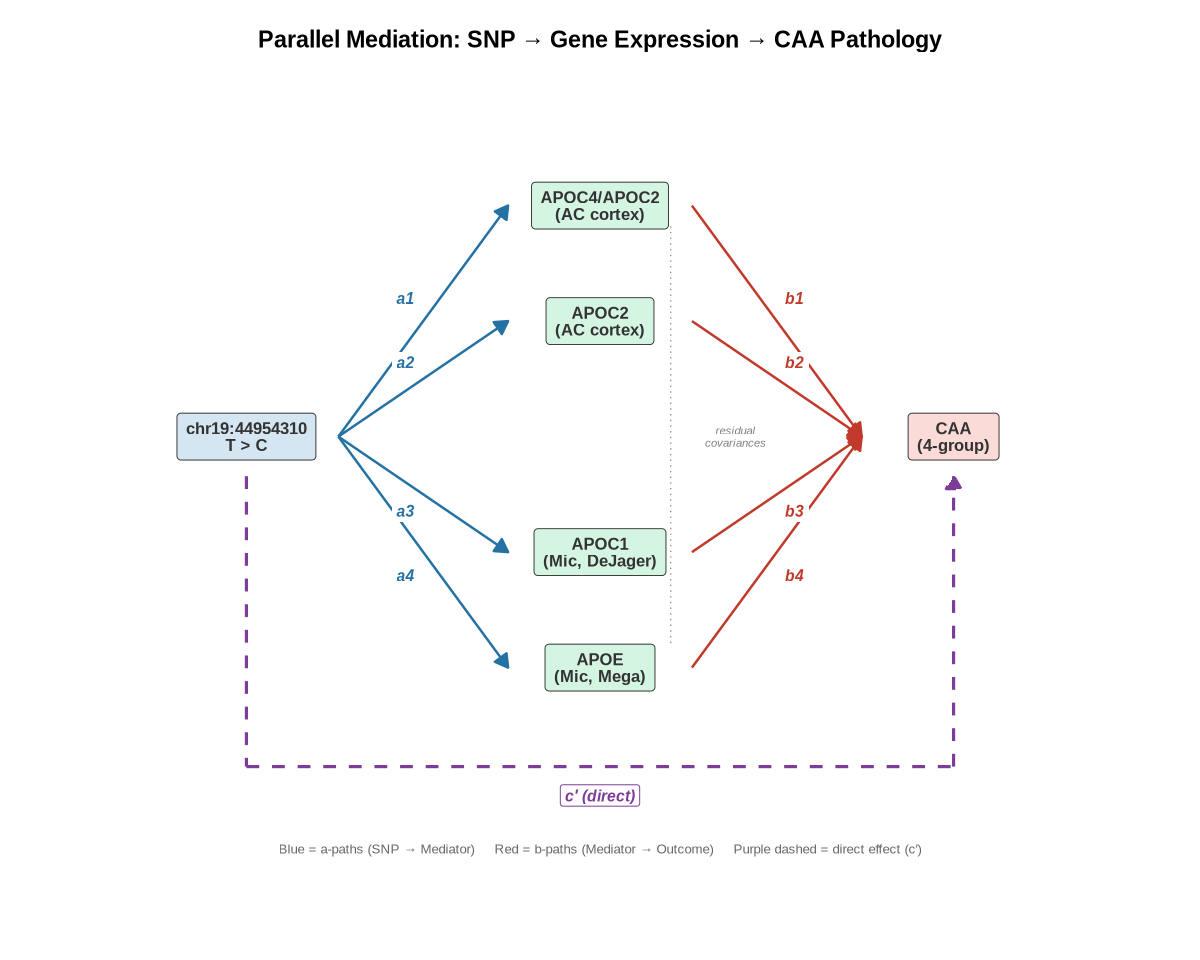

In [1]:
# ============================================================
# DAG: Parallel Mediation Model
# ============================================================
suppressPackageStartupMessages({
  library(ggplot2)
  library(grid)
})

# --- Node positions ---
# SNP left (0,3), 4 mediators center, Outcome right (6,3)
nodes <- data.frame(
  label = c("chr19:44954310\nT > C",
            "APOC4/APOC2\n(AC cortex)",
            "APOC2\n(AC cortex)",
            "APOC1\n(Mic, DeJager)",
            "APOE\n(Mic, Mega)",
            "CAA\n(4-group)"),
  short = c("X", "M1", "M2", "M3", "M4", "Y"),
  x = c(0, 3, 3, 3, 3, 6),
  y = c(3, 5.8, 4.4, 1.6, 0.2, 3),
  fill = c("#D4E6F1", "#D5F5E3", "#D5F5E3", "#D5F5E3", "#D5F5E3", "#FADBD8"),
  stringsAsFactors = FALSE
)

# Box dimensions for arrow offsets
bw <- 0.78
bh <- 0.48

# --- a-paths: X -> M1..M4 ---
a_paths <- data.frame(
  x    = rep(0 + bw, 4),
  y    = rep(3, 4),
  xend = rep(3 - bw, 4),
  yend = c(5.8, 4.4, 1.6, 0.2),
  lab  = c("a1", "a2", "a3", "a4"),
  # Offset labels: a1,a2 above midpoint; a3,a4 below midpoint
  lab_nudge_y = c(0.28, 0.20, -0.20, -0.28),
  lab_nudge_x = c(-0.15, -0.15, -0.15, -0.15),
  stringsAsFactors = FALSE
)

# --- b-paths: M1..M4 -> Y ---
b_paths <- data.frame(
  x    = rep(3 + bw, 4),
  y    = c(5.8, 4.4, 1.6, 0.2),
  xend = rep(6 - bw, 4),
  yend = rep(3, 4),
  lab  = c("b1", "b2", "b3", "b4"),
  lab_nudge_y = c(0.28, 0.20, -0.20, -0.28),
  lab_nudge_x = c(0.15, 0.15, 0.15, 0.15),
  stringsAsFactors = FALSE
)

# --- Direct path: X -> Y, routed BELOW all mediators ---
# Three-segment path: down from X, across bottom, up to Y
direct_y <- -1.0  # well below APOE at y=0.2

direct_segs <- data.frame(
  x    = c(0,       0,         6),
  y    = c(3 - bh,  direct_y,  direct_y),
  xend = c(0,       6,         6),
  yend = c(direct_y, direct_y, 3 - bh),
  stringsAsFactors = FALSE
)

# --- Build plot ---
p_dag <- ggplot() +

  # a-path arrows (blue)
  geom_segment(data = a_paths,
               aes(x = x, y = y, xend = xend, yend = yend),
               color = "#2471A3", linewidth = 0.7,
               arrow = arrow(length = unit(0.12, "inches"), type = "closed")) +
  # a-path labels
  geom_label(data = a_paths,
             aes(x = (x + xend)/2 + lab_nudge_x,
                 y = (y + yend)/2 + lab_nudge_y,
                 label = lab),
             size = 3.3, fill = "white", label.size = 0, fontface = "bold.italic",
             color = "#2471A3") +

  # b-path arrows (red)
  geom_segment(data = b_paths,
               aes(x = x, y = y, xend = xend, yend = yend),
               color = "#C0392B", linewidth = 0.7,
               arrow = arrow(length = unit(0.12, "inches"), type = "closed")) +
  # b-path labels
  geom_label(data = b_paths,
             aes(x = (x + xend)/2 + lab_nudge_x,
                 y = (y + yend)/2 + lab_nudge_y,
                 label = lab),
             size = 3.3, fill = "white", label.size = 0, fontface = "bold.italic",
             color = "#C0392B") +

  # Direct effect: 3 segments (down, across, up), only last has arrow
  geom_segment(aes(x = direct_segs$x[1], y = direct_segs$y[1],
                   xend = direct_segs$xend[1], yend = direct_segs$yend[1]),
               color = "#7D3C98", linewidth = 0.9, linetype = "dashed") +
  geom_segment(aes(x = direct_segs$x[2], y = direct_segs$y[2],
                   xend = direct_segs$xend[2], yend = direct_segs$yend[2]),
               color = "#7D3C98", linewidth = 0.9, linetype = "dashed") +
  geom_segment(aes(x = direct_segs$x[3], y = direct_segs$y[3],
                   xend = direct_segs$xend[3], yend = direct_segs$yend[3]),
               color = "#7D3C98", linewidth = 0.9, linetype = "dashed",
               arrow = arrow(length = unit(0.12, "inches"), type = "closed")) +
  annotate("label", x = 3, y = direct_y - 0.35, label = "c\u2032 (direct)",
           size = 3.3, fill = "white", label.size = 0, fontface = "bold.italic",
           color = "#7D3C98") +

  # Residual covariances: subtle brace on the right of mediators
  annotate("segment", x = 3.6, y = 5.55, xend = 3.6, yend = 0.45,
           linetype = "dotted", color = "grey60", linewidth = 0.4) +
  annotate("text", x = 4.15, y = 3.0, label = "residual\ncovariances",
           size = 2.4, color = "grey50", fontface = "italic", lineheight = 0.9) +

  # Node boxes (drawn last so they sit on top)
  geom_label(data = nodes,
             aes(x = x, y = y, label = label, fill = fill),
             size = 3.5, fontface = "bold",
             label.padding = unit(0.45, "lines"),
             label.r = unit(0.2, "lines"),
             color = "grey20", lineheight = 0.85) +
  scale_fill_identity() +

  # Legend
  annotate("text", x = 3, y = -2.0,
           label = "Blue = a-paths (SNP \u2192 Mediator)     Red = b-paths (Mediator \u2192 Outcome)     Purple dashed = direct effect (c\u2032)",
           size = 2.8, color = "grey40") +

  # Title
  labs(title = "Parallel Mediation: SNP \u2192 Gene Expression \u2192 CAA Pathology") +
  coord_fixed(ratio = 0.7, xlim = c(-1.5, 7.5), ylim = c(-2.5, 7)) +
  theme_void(base_size = 12) +
  theme(plot.title = element_text(hjust = 0.5, size = 14, face = "bold",
                                  margin = margin(b = 8)),
        plot.margin = margin(10, 10, 10, 10))

options(repr.plot.width = 10, repr.plot.height = 8)
print(p_dag)


---

## Input Specification

- **Data file**: `APOE_ind_set_27_caa_4gp_mediation_all_input.txt`
- **Exposure**: `chr19_44954310_T_C` (APOE-region SNP)
- **Mediators** (all 4 in parallel):
  - M1: `APOC4_APOC2_AC_exp` (covariates: msex_u, age_death_u, pmi_u, ROS_study_u)
  - M2: `APOC2_AC_exp` (covariates: msex_u, age_death_u, pmi_u, ROS_study_u)
  - M3: `APOC1_DeJager_Mic_exp` (covariates: msex_u, age_death_u, pmi_u)
  - M4: `APOE_Mega_Mic_exp` (covariates: msex_u, age_death_u, pmi_u)
- **Outcome**: `caa_4gp` (covariates: educ, apoe4_dose, apoe2_dose, msex_u, age_death_u)
- **Direction**: Unidirectional (SNP -> M -> Y only)

---

## Setup

In [3]:
# ============================================================
# 1. Setup: Libraries, Paths, Parameters
# ============================================================
suppressPackageStartupMessages({
  library(lavaan)
  library(blavaan)
  library(ggplot2)
  library(gridExtra)
  library(reshape2)
})

# --- Paths ---
DATA_FILE <- "/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/caa_4gp/APOE_ind_set_27_caa_4gp_mediation_all_input.txt"
RESULT_DIR <- "/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/caa_4gp"

DIR_FIML  <- file.path(RESULT_DIR, "main_SEM_FIML")
DIR_BOOT  <- file.path(RESULT_DIR, "bootstrap")
DIR_MNAR  <- file.path(RESULT_DIR, "MNAR_sensitivity")
DIR_BAYES <- file.path(RESULT_DIR, "bayesian_blavaan")
DIR_SUMM  <- file.path(RESULT_DIR, "summary")

for (d in c(DIR_FIML, DIR_BOOT, DIR_MNAR, DIR_BAYES, DIR_SUMM)) {
  dir.create(d, showWarnings=FALSE, recursive=TRUE)
}

EXPOSURE  <- "chr19_44954310_T_C"
MEDIATORS <- c("APOC4_APOC2_AC_exp", "APOC2_AC_exp", "APOC1_DeJager_Mic_exp", "APOE_Mega_Mic_exp")
MED_LABELS <- c("APOC4_APOC2_AC", "APOC2_AC", "APOC1_DeJager_Mic", "APOE_Mega_Mic")
OUTCOME   <- "caa_4gp"
N_BOOT    <- 1000

MED_COVS <- list(
  APOC4_APOC2_AC_exp     = c("msex_u", "age_death_u", "pmi_u", "ROS_study_u"),
  APOC2_AC_exp           = c("msex_u", "age_death_u", "pmi_u", "ROS_study_u"),
  APOC1_DeJager_Mic_exp  = c("msex_u", "age_death_u", "pmi_u"),
  APOE_Mega_Mic_exp      = c("msex_u", "age_death_u", "pmi_u")
)
OUT_COVS <- c("educ", "apoe4_dose", "apoe2_dose", "msex_u", "age_death_u")
ALL_COVS <- unique(c(unlist(MED_COVS), OUT_COVS))

cat("Setup complete.\n")
cat("Exposure:", EXPOSURE, "\n")
cat("Mediators:", paste(MEDIATORS, collapse=", "), "\n")
cat("Outcome:", OUTCOME, "\n")
cat("All covariates:", paste(ALL_COVS, collapse=", "), "\n")


Setup complete.


Exposure: chr19_44954310_T_C 


Mediators: APOC4_APOC2_AC_exp, APOC2_AC_exp, APOC1_DeJager_Mic_exp, APOE_Mega_Mic_exp 


Outcome: caa_4gp 


All covariates: msex_u, age_death_u, pmi_u, ROS_study_u, educ, apoe4_dose, apoe2_dose 


---

## Data Loading and Exploration

In [4]:
# ============================================================
# 2. Load Data
# ============================================================
dat_raw <- read.delim(DATA_FILE, stringsAsFactors=FALSE)
cat("Raw data dimensions:", nrow(dat_raw), "x", ncol(dat_raw), "\n")

keep_cols <- c("SID", EXPOSURE, MEDIATORS, OUTCOME, ALL_COVS)
missing_cols <- setdiff(keep_cols, colnames(dat_raw))
if (length(missing_cols) > 0) {
  cat("WARNING: Missing columns:", paste(missing_cols, collapse=", "), "\n")
}
dat <- dat_raw[, intersect(keep_cols, colnames(dat_raw))]

for (col in setdiff(colnames(dat), "SID")) {
  dat[[col]] <- as.numeric(dat[[col]])
}

cat("Working data dimensions:", nrow(dat), "x", ncol(dat), "\n")
head(dat)


Raw data dimensions: 1153 x 57 


Working data dimensions: 1153 x 14 


,SID,chr19_44954310_T_C,APOC4_APOC2_AC_exp,APOC2_AC_exp,APOC1_DeJager_Mic_exp,APOE_Mega_Mic_exp,caa_4gp,msex_u,age_death_u,pmi_u,ROS_study_u,educ,apoe4_dose,apoe2_dose
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,MAP15387421,1,NA,NA,1.7786686,1.0499480,NA,0,92.40246,8.833333,NA,NA,NA,NA
2,MAP26637867,0,NA,NA,NA,0.6535373,NA,0,91.24435,7.450000,NA,NA,NA,NA
3,MAP29629849,0,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,MAP33332646,1,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,MAP34726040,0,NA,NA,NA,1.3685606,NA,1,72.82683,4.666667,NA,NA,NA,NA
6,MAP46246604,0,NA,NA,0.4611292,-0.5313924,NA,0,89.44832,3.750000,NA,NA,NA,NA


In [5]:
# ============================================================
# 3. Missingness Summary
# ============================================================
key_vars <- c(EXPOSURE, MEDIATORS, OUTCOME)
miss_df <- data.frame(
  Variable = key_vars,
  N_observed = sapply(key_vars, function(v) sum(!is.na(dat[[v]]))),
  N_missing  = sapply(key_vars, function(v) sum(is.na(dat[[v]]))),
  Pct_missing = sapply(key_vars, function(v) round(100*mean(is.na(dat[[v]])), 1))
)
rownames(miss_df) <- NULL
print(miss_df)

cat("\nTotal subjects:", nrow(dat), "\n")
cat("Subjects with SNP observed:", sum(!is.na(dat[[EXPOSURE]])), "\n")

cat("\nPairwise overlap (N with both variables observed):\n")
overlap_mat <- matrix(NA, length(key_vars), length(key_vars),
                      dimnames=list(key_vars, key_vars))
for (i in seq_along(key_vars)) {
  for (j in seq_along(key_vars)) {
    overlap_mat[i,j] <- sum(!is.na(dat[[key_vars[i]]]) & !is.na(dat[[key_vars[j]]]))
  }
}
print(overlap_mat)


               Variable N_observed N_missing Pct_missing
1    chr19_44954310_T_C       1153         0         0.0
2    APOC4_APOC2_AC_exp        593       560        48.6
3          APOC2_AC_exp        593       560        48.6
4 APOC1_DeJager_Mic_exp        419       734        63.7
5     APOE_Mega_Mic_exp        733       420        36.4
6               caa_4gp       1050       103         8.9



Total subjects: 1153 


Subjects with SNP observed: 1153 



Pairwise overlap (N with both variables observed):


                      chr19_44954310_T_C APOC4_APOC2_AC_exp APOC2_AC_exp
chr19_44954310_T_C                  1153                593          593
APOC4_APOC2_AC_exp                   593                593          593
APOC2_AC_exp                         593                593          593
APOC1_DeJager_Mic_exp                419                311          311
APOE_Mega_Mic_exp                    733                514          514
caa_4gp                             1050                564          564
                      APOC1_DeJager_Mic_exp APOE_Mega_Mic_exp caa_4gp
chr19_44954310_T_C                      419               733    1050
APOC4_APOC2_AC_exp                      311               514     564
APOC2_AC_exp                            311               514     564
APOC1_DeJager_Mic_exp                   419               417     387
APOE_Mega_Mic_exp                       417               733     677
caa_4gp                                 387               677    1050

---

## Model Specification

### Parallel Mediation with Covariates-in-Model (Strategy A)

Each mediator equation includes its own covariates. The outcome equation includes its own covariates.
Residual covariances between mediators are freely estimated (lavaan default).

In [6]:
# ============================================================
# 4. Build Parallel Mediation Model String
# ============================================================
n_med <- length(MEDIATORS)

med_eqs <- character(n_med)
for (k in 1:n_med) {
  cov_str <- paste(MED_COVS[[MEDIATORS[k]]], collapse=" + ")
  med_eqs[k] <- paste0(MEDIATORS[k], " ~ a", k, " * ", EXPOSURE, " + ", cov_str)
}

y_med_terms <- paste0("b", 1:n_med, " * ", MEDIATORS, collapse=" + ")
out_cov_str <- paste(OUT_COVS, collapse=" + ")
y_eq <- paste0(OUTCOME, " ~ ", y_med_terms, " + cp * ", EXPOSURE, " + ", out_cov_str)

# Residual covariances between mediators (NOT estimated by default in lavaan
# for endogenous variables -- must be specified explicitly)
med_covs <- c()
for (i in 1:(n_med-1)) {
  for (j in (i+1):n_med) {
    med_covs <- c(med_covs, paste0(MEDIATORS[i], " ~~ ", MEDIATORS[j]))
  }
}

ind_defs <- paste0("ind", 1:n_med, " := a", 1:n_med, " * b", 1:n_med)
total_ind <- paste0("total_indirect := ", paste0("ind", 1:n_med, collapse=" + "))
total_def <- "total := cp + total_indirect"
prop_def <- "prop_med := total_indirect / total"

contrasts <- c()
for (i in 1:(n_med-1)) {
  for (j in (i+1):n_med) {
    contrasts <- c(contrasts, paste0("diff_", i, "_", j, " := ind", i, " - ind", j))
  }
}

model_str <- paste(c(med_eqs, y_eq, med_covs, ind_defs, total_ind, total_def, prop_def, contrasts),
                   collapse="\n")

cat("Model specification:\n")
cat(model_str, "\n")

Model specification:


APOC4_APOC2_AC_exp ~ a1 * chr19_44954310_T_C + msex_u + age_death_u + pmi_u + ROS_study_u
APOC2_AC_exp ~ a2 * chr19_44954310_T_C + msex_u + age_death_u + pmi_u + ROS_study_u
APOC1_DeJager_Mic_exp ~ a3 * chr19_44954310_T_C + msex_u + age_death_u + pmi_u
APOE_Mega_Mic_exp ~ a4 * chr19_44954310_T_C + msex_u + age_death_u + pmi_u
caa_4gp ~ b1 * APOC4_APOC2_AC_exp + b2 * APOC2_AC_exp + b3 * APOC1_DeJager_Mic_exp + b4 * APOE_Mega_Mic_exp + cp * chr19_44954310_T_C + educ + apoe4_dose + apoe2_dose + msex_u + age_death_u
APOC4_APOC2_AC_exp ~~ APOC2_AC_exp
APOC4_APOC2_AC_exp ~~ APOC1_DeJager_Mic_exp
APOC4_APOC2_AC_exp ~~ APOE_Mega_Mic_exp
APOC2_AC_exp ~~ APOC1_DeJager_Mic_exp
APOC2_AC_exp ~~ APOE_Mega_Mic_exp
APOC1_DeJager_Mic_exp ~~ APOE_Mega_Mic_exp
ind1 := a1 * b1
ind2 := a2 * b2
ind3 := a3 * b3
ind4 := a4 * b4
total_indirect := ind1 + ind2 + ind3 + ind4
total := cp + total_indirect
prop_med := total_indirect / total
diff_1_2 := ind1 - ind2
diff_1_3 := ind1 - ind3
diff_1_4 := ind1 - ind4
diff

---

## Method 1: FIML SEM (lavaan)

Full Information Maximum Likelihood handles missing data by using ALL available observations.
With `fixed.x=FALSE`, the SNP is treated as a random variable, allowing subjects with only
the SNP observed to contribute to parameter estimation.

In [7]:
# ============================================================
# 5. FIML SEM
# ============================================================
cat("Fitting FIML SEM...\n")

fit_fiml <- tryCatch(
  sem(model_str, data=dat, missing="fiml", fixed.x=FALSE, estimator="ML"),
  error = function(e) { cat("FIML Error:", e$message, "\n"); NULL }
)

if (!is.null(fit_fiml)) {
  cat("FIML converged:", lavInspect(fit_fiml, "converged"), "\n")
  N_fiml <- lavInspect(fit_fiml, "ntotal")
  cat("N used:", N_fiml, "\n\n")

  pe <- parameterEstimates(fit_fiml, ci=TRUE)
  labeled <- pe[pe$label != "", c("label", "est", "se", "ci.lower", "ci.upper", "pvalue")]
  labeled$N <- N_fiml
  labeled$method <- "FIML"
  print(labeled)

  write.csv(labeled, file.path(DIR_FIML, "fiml_all_paths.csv"), row.names=FALSE)
  cat("\nFIML results saved.\n")

  fm <- fitMeasures(fit_fiml, c("chisq","df","pvalue","cfi","tli","rmsea","srmr","aic","bic"))
  fm_df <- data.frame(measure=names(fm), value=round(as.numeric(fm), 4), N=N_fiml)
  write.csv(fm_df, file.path(DIR_FIML, "fiml_fit_measures.csv"), row.names=FALSE)
  print(fm_df)
}


Fitting FIML SEM...


FIML converged: TRUE 
N used: 1153 

             label    est    se ci.lower ci.upper pvalue    N method
1               a1  0.279 0.056    0.169    0.389  0.000 1153   FIML
6               a2  0.276 0.056    0.166    0.386  0.000 1153   FIML
11              a3  0.226 0.064    0.100    0.351  0.000 1153   FIML
15              a4  0.213 0.049    0.117    0.309  0.000 1153   FIML
19              b1 -0.858 0.946   -2.711    0.996  0.364 1153   FIML
20              b2  0.780 0.945   -1.072    2.632  0.409 1153   FIML
21              b3  0.054 0.058   -0.060    0.167  0.355 1153   FIML
22              b4  0.033 0.051   -0.066    0.132  0.515 1153   FIML
23              cp  0.140 0.040    0.062    0.219  0.000 1153   FIML
89            ind1 -0.239 0.268   -0.765    0.287  0.373 1153   FIML
90            ind2  0.215 0.264   -0.303    0.733  0.416 1153   FIML
91            ind3  0.012 0.014   -0.015    0.039  0.379 1153   FIML
92            ind4  0.007 0.011   -0.014    0.028  0.519 1153   FI

FIML forest plot saved.


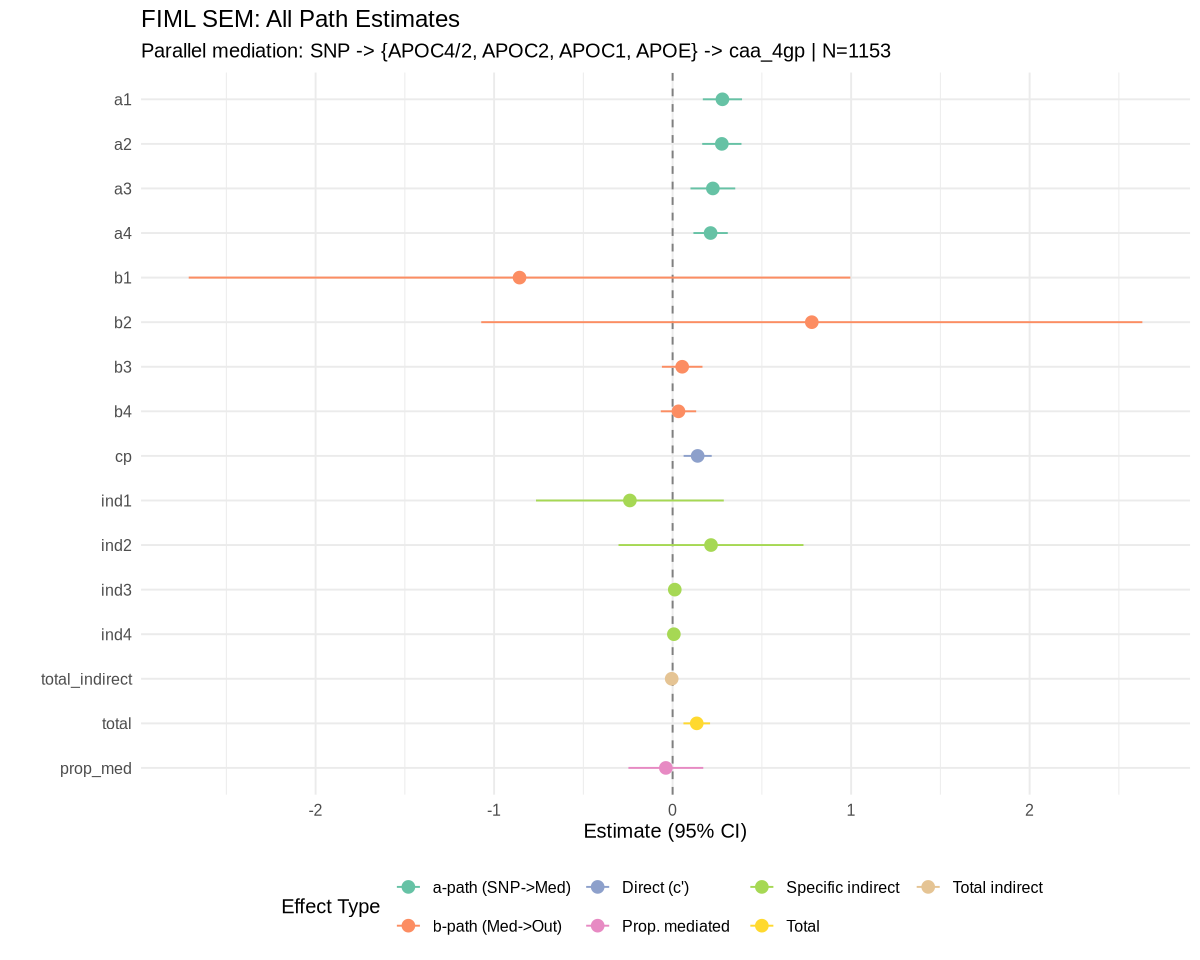

In [8]:
# ============================================================
# 5b. FIML Forest Plot
# ============================================================
if (!is.null(fit_fiml)) {
  plot_df <- labeled[!grepl("^diff_", labeled$label), ]
  plot_df$label <- factor(plot_df$label,
    levels=rev(c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                 paste0("ind", 1:n_med), "total_indirect", "total", "prop_med")))

  plot_df$effect_type <- ifelse(grepl("^a", plot_df$label), "a-path (SNP->Med)",
                        ifelse(grepl("^b", plot_df$label), "b-path (Med->Out)",
                        ifelse(plot_df$label == "cp", "Direct (c')",
                        ifelse(grepl("^ind", plot_df$label), "Specific indirect",
                        ifelse(plot_df$label == "total_indirect", "Total indirect",
                        ifelse(plot_df$label == "total", "Total", "Prop. mediated"))))))

  p_fiml <- ggplot(plot_df, aes(x=est, y=label, color=effect_type)) +
    geom_vline(xintercept=0, linetype="dashed", color="grey50") +
    geom_pointrange(aes(xmin=ci.lower, xmax=ci.upper), size=0.6) +
    scale_color_brewer(palette="Set2") +
    labs(title="FIML SEM: All Path Estimates",
         subtitle=paste0("Parallel mediation: SNP -> {APOC4/2, APOC2, APOC1, APOE} -> caa_4gp | N=", N_fiml),
         x="Estimate (95% CI)", y="", color="Effect Type") +
    theme_minimal(base_size=12) +
    theme(legend.position="bottom")

  print(p_fiml)
  ggsave(file.path(DIR_FIML, "fiml_forest_plot.png"), p_fiml, width=10, height=8, dpi=150)
  ggsave(file.path(DIR_FIML, "fiml_forest_plot.pdf"), p_fiml, width=10, height=8)
  cat("FIML forest plot saved.\n")
}


### Sensitivity Analysis: 3-Mediator Model (Excluding APOC4/APOC2)

Due to high collinearity between APOC4/APOC2 (AC cortex) and APOC2 (AC cortex),
we re-run the FIML SEM excluding APOC4_APOC2_AC_exp to assess robustness of the
remaining mediator effects and the direct effect.

=== Sensitivity Analysis: 3-Mediator Model (excluding APOC4_APOC2_AC_exp) ===



3-Mediator Model specification:


APOC2_AC_exp ~ a1 * chr19_44954310_T_C + msex_u + age_death_u + pmi_u + ROS_study_u
APOC1_DeJager_Mic_exp ~ a2 * chr19_44954310_T_C + msex_u + age_death_u + pmi_u
APOE_Mega_Mic_exp ~ a3 * chr19_44954310_T_C + msex_u + age_death_u + pmi_u
caa_4gp ~ b1 * APOC2_AC_exp + b2 * APOC1_DeJager_Mic_exp + b3 * APOE_Mega_Mic_exp + cp * chr19_44954310_T_C + educ + apoe4_dose + apoe2_dose + msex_u + age_death_u
APOC2_AC_exp ~~ APOC1_DeJager_Mic_exp
APOC2_AC_exp ~~ APOE_Mega_Mic_exp
APOC1_DeJager_Mic_exp ~~ APOE_Mega_Mic_exp
ind1 := a1 * b1
ind2 := a2 * b2
ind3 := a3 * b3
total_indirect := ind1 + ind2 + ind3
total := cp + total_indirect
prop_med := total_indirect / total
diff_1_2 := ind1 - ind2
diff_1_3 := ind1 - ind3
diff_2_3 := ind2 - ind3 



Converged: TRUE 
N used: 1153 

            label    est    se ci.lower ci.upper pvalue    N
1              a1  0.276 0.056    0.166    0.386  0.000 1153
6              a2  0.226 0.064    0.100    0.351  0.000 1153
10             a3  0.213 0.049    0.116    0.309  0.000 1153
14             b1 -0.077 0.039   -0.153    0.000  0.049 1153
15             b2  0.061 0.058   -0.052    0.174  0.293 1153
16             b3  0.031 0.050   -0.068    0.130  0.544 1153
17             cp  0.136 0.040    0.058    0.214  0.001 1153
78           ind1 -0.021 0.012   -0.044    0.002  0.069 1153
79           ind2  0.014 0.014   -0.013    0.041  0.323 1153
80           ind3  0.007 0.011   -0.015    0.028  0.548 1153
81 total_indirect -0.001 0.014   -0.028    0.026  0.943 1153
82          total  0.135 0.038    0.060    0.210  0.000 1153
83       prop_med -0.007 0.101   -0.205    0.191  0.943 1153
84       diff_1_2 -0.035 0.021   -0.075    0.006  0.091 1153
85       diff_1_3 -0.028 0.015   -0.056    0.001  0.0

Warning message:
“`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.”


`height` was translated to `width`.


`height` was translated to `width`.


`height` was translated to `width`.


Forest plot saved.


=== Comparison: 4-Mediator vs 3-Mediator Model ===
Measure                     4-Mediator   3-Mediator
-------------------------------------------------- 
CFI                             0.9976       0.9793
TLI                             0.9924       0.9396
RMSEA                           0.0239       0.0243
SRMR                            0.0202       0.0207
AIC                         34160.9094   36350.2748
BIC                         34605.3202   36739.1343

--- Key path comparison ---
Parameter                 4-Med est(p) 3-Med est(p)
-------------------------------------------------- 
cp (direct)                0.1403(0.000)  0.1359(0.001)
total_indirect            -0.0051(0.721) -0.0010(0.943)
total                      0.1352(0.000)  0.1350(0.000)

Comparison table saved.


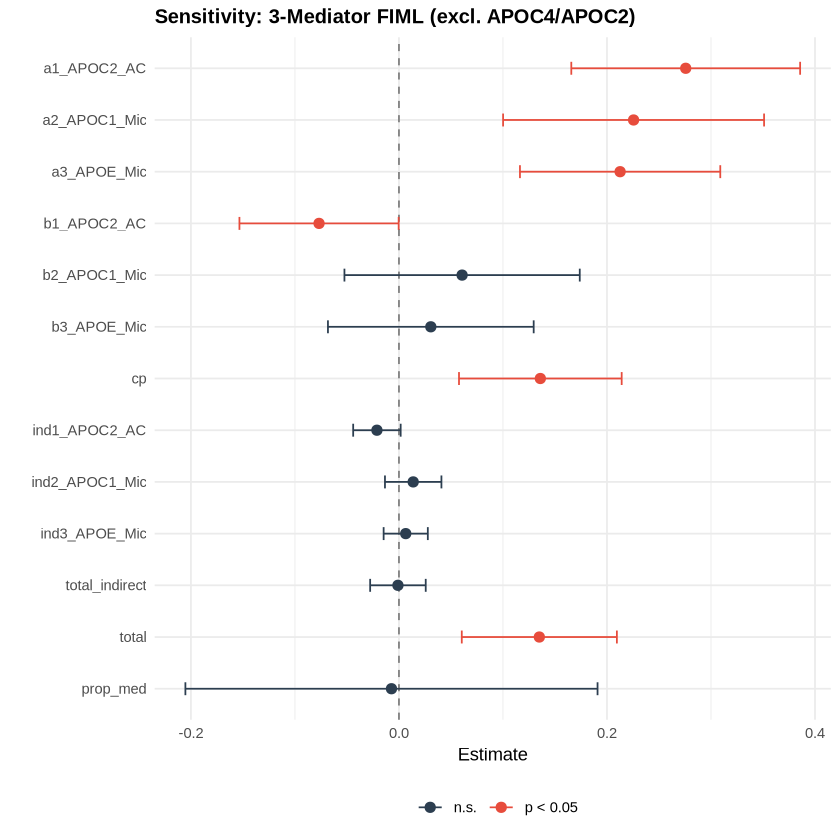

In [6]:
# ============================================================
# 5c. Sensitivity: FIML SEM without APOC4_APOC2_AC_exp
# ============================================================
DIR_SENS <- file.path(DIR_FIML, "sensitivity_analysis")
dir.create(DIR_SENS, showWarnings=FALSE, recursive=TRUE)

cat("=== Sensitivity Analysis: 3-Mediator Model (excluding APOC4_APOC2_AC_exp) ===\n\n")

MEDIATORS_3 <- c("APOC2_AC_exp", "APOC1_DeJager_Mic_exp", "APOE_Mega_Mic_exp")
MED_LABELS_3 <- c("APOC2_AC", "APOC1_DeJager_Mic", "APOE_Mega_Mic")
n_med_3 <- length(MEDIATORS_3)

# Build model string for 3 mediators
med_eqs_3 <- character(n_med_3)
for (k in 1:n_med_3) {
  cov_str <- paste(MED_COVS[[MEDIATORS_3[k]]], collapse=" + ")
  med_eqs_3[k] <- paste0(MEDIATORS_3[k], " ~ a", k, " * ", EXPOSURE, " + ", cov_str)
}

y_med_terms_3 <- paste0("b", 1:n_med_3, " * ", MEDIATORS_3, collapse=" + ")
y_eq_3 <- paste0(OUTCOME, " ~ ", y_med_terms_3, " + cp * ", EXPOSURE, " + ", out_cov_str)

# Residual covariances between 3 mediators
med_covs_3 <- c()
for (i in 1:(n_med_3-1)) {
  for (j in (i+1):n_med_3) {
    med_covs_3 <- c(med_covs_3, paste0(MEDIATORS_3[i], " ~~ ", MEDIATORS_3[j]))
  }
}

ind_defs_3 <- paste0("ind", 1:n_med_3, " := a", 1:n_med_3, " * b", 1:n_med_3)
total_ind_3 <- paste0("total_indirect := ", paste0("ind", 1:n_med_3, collapse=" + "))
total_def_3 <- "total := cp + total_indirect"
prop_def_3 <- "prop_med := total_indirect / total"

contrasts_3 <- c()
for (i in 1:(n_med_3-1)) {
  for (j in (i+1):n_med_3) {
    contrasts_3 <- c(contrasts_3, paste0("diff_", i, "_", j, " := ind", i, " - ind", j))
  }
}

model_str_3 <- paste(c(med_eqs_3, y_eq_3, med_covs_3, ind_defs_3, total_ind_3,
                        total_def_3, prop_def_3, contrasts_3), collapse="\n")

cat("3-Mediator Model specification:\n")
cat(model_str_3, "\n\n")

# Fit
fit_sens <- tryCatch(
  sem(model_str_3, data=dat, missing="fiml", fixed.x=FALSE, estimator="ML"),
  error = function(e) { cat("FIML Error:", e$message, "\n"); NULL }
)

if (!is.null(fit_sens)) {
  cat("Converged:", lavInspect(fit_sens, "converged"), "\n")
  N_sens <- lavInspect(fit_sens, "ntotal")
  cat("N used:", N_sens, "\n\n")

  pe_s <- parameterEstimates(fit_sens, ci=TRUE)
  labeled_s <- pe_s[pe_s$label != "", c("label", "est", "se", "ci.lower", "ci.upper", "pvalue")]
  labeled_s$N <- N_sens
  labeled_s$method <- "FIML_sensitivity_3med"

  # Rename labels for clarity: a1->a1(APOC2), a2->a2(APOC1), a3->a3(APOE)
  med_map_3 <- c("a1"="a1_APOC2_AC", "a2"="a2_APOC1_Mic", "a3"="a3_APOE_Mic",
                  "b1"="b1_APOC2_AC", "b2"="b2_APOC1_Mic", "b3"="b3_APOE_Mic",
                  "ind1"="ind1_APOC2_AC", "ind2"="ind2_APOC1_Mic", "ind3"="ind3_APOE_Mic",
                  "diff_1_2"="diff_APOC2_vs_APOC1", "diff_1_3"="diff_APOC2_vs_APOE",
                  "diff_2_3"="diff_APOC1_vs_APOE")
  labeled_s$label_full <- ifelse(labeled_s$label %in% names(med_map_3),
                                  med_map_3[labeled_s$label], labeled_s$label)

  print(labeled_s)

  write.csv(labeled_s, file.path(DIR_SENS, "fiml_3med_all_paths.csv"), row.names=FALSE)
  cat("\n3-mediator FIML results saved.\n")

  # Fit measures
  fm_s <- fitMeasures(fit_sens, c("chisq","df","pvalue","cfi","tli","rmsea","srmr","aic","bic"))
  fm_s_df <- data.frame(measure=names(fm_s), value=round(as.numeric(fm_s), 4), N=N_sens)
  write.csv(fm_s_df, file.path(DIR_SENS, "fiml_3med_fit_measures.csv"), row.names=FALSE)
  cat("\nFit measures (3-mediator model):\n")
  print(fm_s_df)

  # Forest plot
  plot_labels <- labeled_s[!grepl("^diff", labeled_s$label), ]
  plot_labels$label <- factor(plot_labels$label_full,
                               levels=rev(plot_labels$label_full))
  plot_labels$sig <- ifelse(plot_labels$pvalue < 0.05, "p < 0.05", "n.s.")

  p_sens <- ggplot(plot_labels, aes(x=est, y=label, color=sig)) +
    geom_vline(xintercept=0, linetype="dashed", color="grey50") +
    geom_point(size=2.5) +
    geom_errorbarh(aes(xmin=ci.lower, xmax=ci.upper), height=0.25) +
    scale_color_manual(values=c("p < 0.05"="#E74C3C", "n.s."="#2C3E50")) +
    labs(title="Sensitivity: 3-Mediator FIML (excl. APOC4/APOC2)",
         x="Estimate", y="", color="") +
    theme_minimal(base_size=11) +
    theme(plot.title=element_text(face="bold", size=12),
          legend.position="bottom")

  ggsave(file.path(DIR_SENS, "fiml_3med_forest_plot.png"), p_sens, width=9, height=6, dpi=150)
  ggsave(file.path(DIR_SENS, "fiml_3med_forest_plot.pdf"), p_sens, width=9, height=6)
  print(p_sens)
  cat("Forest plot saved.\n")

  # Comparison table: 4-med vs 3-med
  cat("\n\n=== Comparison: 4-Mediator vs 3-Mediator Model ===\n")
  cat(sprintf("%-25s %12s %12s\n", "Measure", "4-Mediator", "3-Mediator"))
  cat(paste(rep("-", 50), collapse=""), "\n")
  fm_4 <- read.csv(file.path(DIR_FIML, "fiml_fit_measures.csv"), stringsAsFactors=FALSE)
  for (m in c("cfi", "tli", "rmsea", "srmr", "aic", "bic")) {
    v4 <- fm_4$value[fm_4$measure == m]
    v3 <- fm_s_df$value[fm_s_df$measure == m]
    cat(sprintf("%-25s %12.4f %12.4f\n", toupper(m), v4, v3))
  }

  # Compare key paths
  cat("\n--- Key path comparison ---\n")
  paths_4 <- read.csv(file.path(DIR_FIML, "fiml_all_paths.csv"), stringsAsFactors=FALSE)
  cat(sprintf("%-25s %12s %12s\n", "Parameter", "4-Med est(p)", "3-Med est(p)"))
  cat(paste(rep("-", 50), collapse=""), "\n")

  # Direct effect
  cp4 <- paths_4[paths_4$label == "cp", ]
  cp3 <- labeled_s[labeled_s$label == "cp", ]
  cat(sprintf("%-25s %7.4f(%.3f) %7.4f(%.3f)\n", "cp (direct)",
              cp4$est, cp4$pvalue, cp3$est, cp3$pvalue))

  # Total indirect
  ti4 <- paths_4[paths_4$label == "total_indirect", ]
  ti3 <- labeled_s[labeled_s$label == "total_indirect", ]
  cat(sprintf("%-25s %7.4f(%.3f) %7.4f(%.3f)\n", "total_indirect",
              ti4$est, ti4$pvalue, ti3$est, ti3$pvalue))

  # Total
  t4 <- paths_4[paths_4$label == "total", ]
  t3 <- labeled_s[labeled_s$label == "total", ]
  cat(sprintf("%-25s %7.4f(%.3f) %7.4f(%.3f)\n", "total",
              t4$est, t4$pvalue, t3$est, t3$pvalue))

  # Save comparison
  comp_df <- data.frame(
    parameter = c("cp", "total_indirect", "total"),
    est_4med = c(cp4$est, ti4$est, t4$est),
    p_4med = c(cp4$pvalue, ti4$pvalue, t4$pvalue),
    est_3med = c(cp3$est, ti3$est, t3$est),
    p_3med = c(cp3$pvalue, ti3$pvalue, t3$pvalue)
  )
  write.csv(comp_df, file.path(DIR_SENS, "comparison_4med_vs_3med.csv"), row.names=FALSE)
  cat("\nComparison table saved.\n")
} else {
  cat("3-mediator FIML model failed to converge.\n")
}

### FIML Interpretation

The FIML SEM provides maximum-likelihood estimates for all paths in the parallel mediation model.

- **a-paths (a1-a4)**: Effect of the SNP on each mediator (gene expression)
- **b-paths (b1-b4)**: Effect of each mediator on CAA, controlling for the SNP and other mediators
- **c' (cp)**: Direct effect of the SNP on CAA, controlling for all four mediators
- **Specific indirects (ind1-ind4)**: Product a_k * b_k -- unique mediated effect through mediator k
- **Total indirect**: Sum of all specific indirects
- **Total**: Direct + total indirect
- **Proportion mediated**: Total indirect / total

---

## Method 2: Bootstrap (FIML inside each replicate)

In [9]:
# ============================================================
# 6. Bootstrap
# ============================================================
cat("Running", N_BOOT, "bootstrap replicates with FIML inside each...\n")

param_labels <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                  paste0("ind", 1:n_med), "total_indirect", "total", "prop_med")

boot_mat <- matrix(NA, N_BOOT, length(param_labels),
                   dimnames=list(NULL, param_labels))

set.seed(42)
n_success <- 0

for (i in 1:N_BOOT) {
  idx <- sample(nrow(dat), replace=TRUE)
  boot_dat <- dat[idx, ]

  fit_b <- tryCatch(
    sem(model_str, data=boot_dat, missing="fiml", fixed.x=FALSE,
        se="none", test="none"),
    error = function(e) NULL,
    warning = function(w) {
      tryCatch(sem(model_str, data=boot_dat, missing="fiml", fixed.x=FALSE,
                   se="none", test="none"),
               error = function(e) NULL)
    }
  )

  if (!is.null(fit_b) && lavInspect(fit_b, "converged")) {
    pe_b <- parameterEstimates(fit_b)
    for (lab in param_labels) {
      row_b <- pe_b[pe_b$label == lab, ]
      if (nrow(row_b) == 1) boot_mat[i, lab] <- row_b$est
    }
    n_success <- n_success + 1
  }

  if (i %% 200 == 0) cat("  Replicate", i, "/", N_BOOT, "(", n_success, "converged)\n")
}

cat("\nBootstrap complete:", n_success, "/", N_BOOT, "replicates converged.\n")


Running 1000 bootstrap replicates with FIML inside each...


  Replicate 200 / 1000 ( 200 converged)
  Replicate 400 / 1000 ( 400 converged)
  Replicate 600 / 1000 ( 600 converged)
  Replicate 800 / 1000 ( 800 converged)
  Replicate 1000 / 1000 ( 1000 converged)



Bootstrap complete: 1000 / 1000 replicates converged.


In [10]:
# ============================================================
# 6b. Bootstrap Summary
# ============================================================
boot_summary <- data.frame(
  label     = param_labels,
  boot_mean = apply(boot_mat, 2, mean, na.rm=TRUE),
  boot_se   = apply(boot_mat, 2, sd, na.rm=TRUE),
  ci_lower  = apply(boot_mat, 2, quantile, 0.025, na.rm=TRUE),
  ci_upper  = apply(boot_mat, 2, quantile, 0.975, na.rm=TRUE),
  stringsAsFactors=FALSE
)

boot_summary$pvalue <- sapply(param_labels, function(lab) {
  vals <- boot_mat[, lab]
  vals <- vals[!is.na(vals)]
  if (length(vals) < 10) return(NA)
  p_pos <- mean(vals > 0)
  2 * min(p_pos, 1 - p_pos)
})

boot_summary$N <- N_fiml
boot_summary$n_replicates <- n_success
boot_summary$method <- "Bootstrap"

print(boot_summary)
write.csv(boot_summary, file.path(DIR_BOOT, "bootstrap_results.csv"), row.names=FALSE)
cat("Bootstrap results saved.\n")


                        label    boot_mean    boot_se    ci_lower   ci_upper
a1                         a1  0.281782714 0.05550201  0.17550243 0.39299885
a2                         a2  0.278635307 0.05565842  0.17336369 0.38852366
a3                         a3  0.223237935 0.06371455  0.09809953 0.35067986
a4                         a4  0.212213238 0.04537182  0.11865467 0.29645833
b1                         b1 -0.923905707 0.91097343 -2.78476849 0.75742884
b2                         b2  0.844422749 0.90858852 -0.84491552 2.70657248
b3                         b3  0.054219971 0.06472397 -0.07144015 0.17624593
b4                         b4  0.033688170 0.05374446 -0.06843109 0.13993094
cp                         cp  0.142829853 0.04227618  0.05811169 0.22685244
ind1                     ind1 -0.260607770 0.26677357 -0.84679260 0.21080194
ind2                     ind2  0.235504131 0.26249354 -0.23254922 0.81172188
ind3                     ind3  0.011676119 0.01501737 -0.01566676 0.04242190

Bootstrap results saved.


Bootstrap forest plot saved.


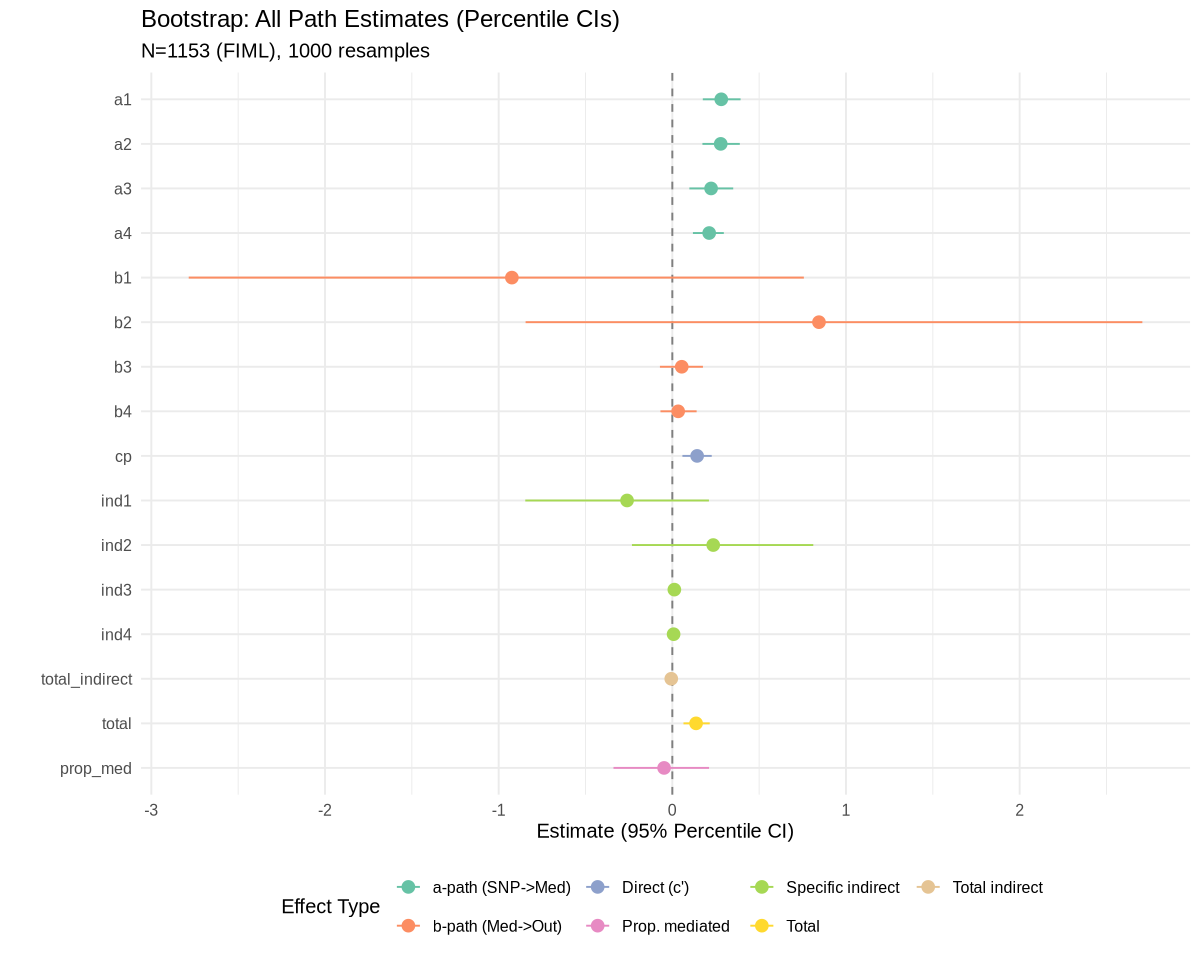

In [11]:
# ============================================================
# 6c. Bootstrap Forest Plot
# ============================================================
plot_boot <- boot_summary[!grepl("^diff_", boot_summary$label), ]
plot_boot$label <- factor(plot_boot$label,
  levels=rev(c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
               paste0("ind", 1:n_med), "total_indirect", "total", "prop_med")))

plot_boot$effect_type <- ifelse(grepl("^a", plot_boot$label), "a-path (SNP->Med)",
                        ifelse(grepl("^b", plot_boot$label), "b-path (Med->Out)",
                        ifelse(plot_boot$label == "cp", "Direct (c')",
                        ifelse(grepl("^ind", plot_boot$label), "Specific indirect",
                        ifelse(plot_boot$label == "total_indirect", "Total indirect",
                        ifelse(plot_boot$label == "total", "Total", "Prop. mediated"))))))

p_boot <- ggplot(plot_boot, aes(x=boot_mean, y=label, color=effect_type)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(aes(xmin=ci_lower, xmax=ci_upper), size=0.6) +
  scale_color_brewer(palette="Set2") +
  labs(title="Bootstrap: All Path Estimates (Percentile CIs)",
       subtitle=paste0("N=", N_fiml, " (FIML), ", n_success, " resamples"),
       x="Estimate (95% Percentile CI)", y="", color="Effect Type") +
  theme_minimal(base_size=12) +
  theme(legend.position="bottom")

print(p_boot)
ggsave(file.path(DIR_BOOT, "bootstrap_forest_plot.png"), p_boot, width=10, height=8, dpi=150)
ggsave(file.path(DIR_BOOT, "bootstrap_forest_plot.pdf"), p_boot, width=10, height=8)
cat("Bootstrap forest plot saved.\n")


Bootstrap distribution histograms saved.


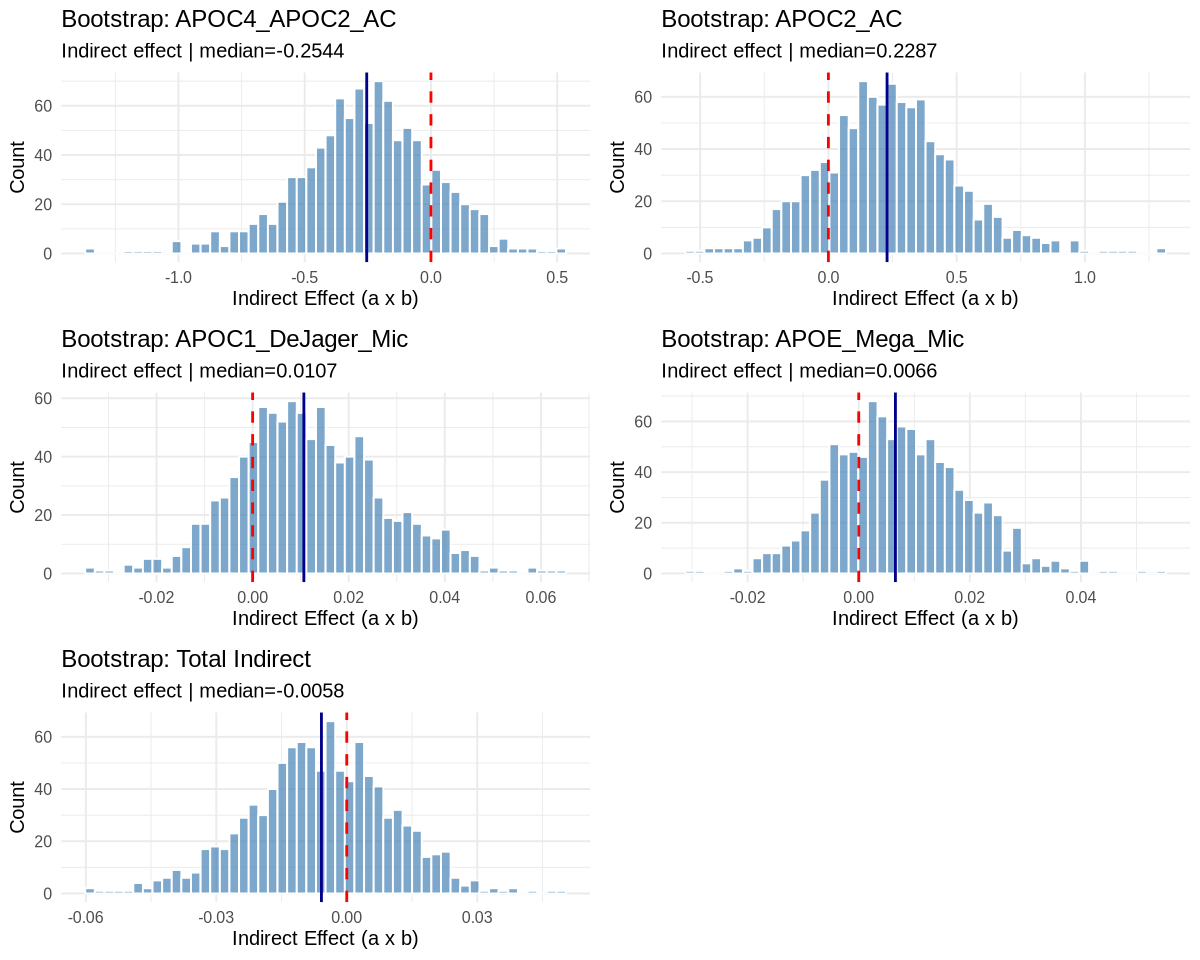

In [12]:
# ============================================================
# 6d. Bootstrap Distribution Histograms
# ============================================================
ind_labels <- c(paste0("ind", 1:n_med), "total_indirect")
ind_names <- c(MED_LABELS, "Total Indirect")

hist_plots <- list()
for (k in seq_along(ind_labels)) {
  vals <- boot_mat[, ind_labels[k]]
  vals <- vals[!is.na(vals)]
  if (length(vals) < 10) next

  df_h <- data.frame(value = vals)
  med_val <- median(vals)

  p_h <- ggplot(df_h, aes(x=value)) +
    geom_histogram(bins=50, fill="steelblue", alpha=0.7, color="white") +
    geom_vline(xintercept=0, linetype="dashed", color="red", linewidth=0.8) +
    geom_vline(xintercept=med_val, linetype="solid", color="darkblue", linewidth=0.8) +
    labs(title=paste0("Bootstrap: ", ind_names[k]),
         subtitle=paste0("Indirect effect | median=", round(med_val, 4)),
         x="Indirect Effect (a x b)", y="Count") +
    theme_minimal(base_size=12)

  hist_plots[[k]] <- p_h
}

if (length(hist_plots) > 0) {
  g <- do.call(grid.arrange, c(hist_plots, ncol=2))
  ggsave(file.path(DIR_BOOT, paste0("bootstrap_distributions_", EXPOSURE, ".png")),
         g, width=12, height=10, dpi=150)
  ggsave(file.path(DIR_BOOT, paste0("bootstrap_distributions_", EXPOSURE, ".pdf")),
         g, width=12, height=10)
  cat("Bootstrap distribution histograms saved.\n")
}


### Bootstrap Interpretation

Bootstrap provides nonparametric inference for the indirect effects.
Percentile confidence intervals that exclude zero indicate significant mediation.
The bootstrap does not assume normality for the product of coefficients (a*b).

---

## Method 3: MNAR Sensitivity Analysis

Missing Not At Random (MNAR) sensitivity analysis tests robustness to potential
informative missingness. We systematically shift imputed values by delta * SD units.

In [13]:
# ============================================================
# 7. MNAR Sensitivity
# ============================================================
cat("Running MNAR sensitivity analysis...\n")

delta_range <- seq(-2, 2, length.out=11)
grid <- expand.grid(delta_med=delta_range, delta_out=delta_range)

med_means <- sapply(MEDIATORS, function(m) mean(dat[[m]], na.rm=TRUE))
med_sds   <- sapply(MEDIATORS, function(m) sd(dat[[m]], na.rm=TRUE))
out_mean  <- mean(dat[[OUTCOME]], na.rm=TRUE)
out_sd    <- sd(dat[[OUTCOME]], na.rm=TRUE)

mnar_params <- c(paste0("ind", 1:n_med), "total_indirect", "cp", "total")
mnar_results <- data.frame()

for (k in 1:nrow(grid)) {
  dat_imp <- dat

  for (m_idx in 1:n_med) {
    m <- MEDIATORS[m_idx]
    miss_m <- is.na(dat_imp[[m]])
    if (any(miss_m)) {
      dat_imp[[m]][miss_m] <- med_means[m_idx] + grid$delta_med[k] * med_sds[m_idx]
    }
  }

  miss_y <- is.na(dat_imp[[OUTCOME]])
  if (any(miss_y)) {
    dat_imp[[OUTCOME]][miss_y] <- out_mean + grid$delta_out[k] * out_sd
  }

  for (cov in ALL_COVS) {
    miss_c <- is.na(dat_imp[[cov]])
    if (any(miss_c)) {
      dat_imp[[cov]][miss_c] <- mean(dat_imp[[cov]], na.rm=TRUE)
    }
  }

  fit_m <- tryCatch(
    sem(model_str, data=dat_imp, estimator="ML", fixed.x=FALSE),
    error = function(e) NULL
  )

  if (!is.null(fit_m) && lavInspect(fit_m, "converged")) {
    pe_m <- parameterEstimates(fit_m, ci=TRUE)
    for (param in mnar_params) {
      row_m <- pe_m[pe_m$label == param, ]
      if (nrow(row_m) == 1) {
        mnar_results <- rbind(mnar_results, data.frame(
          delta_med = grid$delta_med[k],
          delta_out = grid$delta_out[k],
          param = param,
          est = row_m$est,
          se = row_m$se,
          pvalue = row_m$pvalue,
          ci_lower = row_m$ci.lower,
          ci_upper = row_m$ci.upper,
          N = nrow(dat_imp),
          stringsAsFactors = FALSE
        ))
      }
    }
  }

  if (k %% 30 == 0) cat("  Grid point", k, "/", nrow(grid), "\n")
}

cat("MNAR sensitivity complete:", nrow(mnar_results), "results.\n")
write.csv(mnar_results, file.path(DIR_MNAR, "mnar_grid_results.csv"), row.names=FALSE)


Running MNAR sensitivity analysis...


  Grid point 30 / 121 
  Grid point 60 / 121 
  Grid point 90 / 121 
  Grid point 120 / 121 


MNAR sensitivity complete: 847 results.


In [14]:
# ============================================================
# 7b. MNAR Tipping Point Analysis
# ============================================================
tipping_summary <- data.frame()

for (param in c(paste0("ind", 1:n_med), "total_indirect")) {
  param_data <- mnar_results[mnar_results$param == param, ]

  ref_row <- param_data[param_data$delta_med == 0 & param_data$delta_out == 0, ]
  ref_sig <- if (nrow(ref_row) > 0) (ref_row$pvalue[1] < 0.05) else NA

  if (is.na(ref_sig)) {
    tipping_summary <- rbind(tipping_summary, data.frame(
      param = param, ref_significant = NA,
      tipping_delta_med = NA, tipping_delta_out = NA,
      tipping_distance = NA,
      N = NA, stringsAsFactors = FALSE
    ))
    next
  }

  if (ref_sig) {
    # Reference IS significant: find closest point where it LOSES significance
    flip_points <- param_data[param_data$pvalue >= 0.05, ]
  } else {
    # Reference is NOT significant: find closest point where it BECOMES significant
    flip_points <- param_data[param_data$pvalue < 0.05, ]
  }

  if (nrow(flip_points) > 0) {
    flip_points$dist <- sqrt(flip_points$delta_med^2 + flip_points$delta_out^2)
    closest <- flip_points[which.min(flip_points$dist), ]
    tipping_summary <- rbind(tipping_summary, data.frame(
      param = param, ref_significant = ref_sig,
      tipping_delta_med = closest$delta_med,
      tipping_delta_out = closest$delta_out,
      tipping_distance = round(closest$dist, 2),
      N = closest$N, stringsAsFactors = FALSE
    ))
  } else {
    # No flip found in the grid: robust
    tipping_summary <- rbind(tipping_summary, data.frame(
      param = param, ref_significant = ref_sig,
      tipping_delta_med = NA, tipping_delta_out = NA,
      tipping_distance = Inf,
      N = if (nrow(ref_row) > 0) ref_row$N[1] else NA, stringsAsFactors = FALSE
    ))
  }
}

cat("MNAR Tipping Point Summary:\n")
cat("(ref_significant = significance at delta=0; tipping = where conclusion flips)\n\n")
print(tipping_summary)
write.csv(tipping_summary, file.path(DIR_MNAR, "mnar_tipping_summary.csv"), row.names=FALSE)
cat("\nMNAR tipping summary saved.\n")

MNAR Tipping Point Summary:


(ref_significant = significance at delta=0; tipping = where conclusion flips)



           param ref_significant tipping_delta_med tipping_delta_out
1           ind1           FALSE                NA                NA
2           ind2           FALSE                NA                NA
3           ind3           FALSE                NA                NA
4           ind4           FALSE                NA                NA
5 total_indirect           FALSE                NA                NA
  tipping_distance    N
1              Inf 1153
2              Inf 1153
3              Inf 1153
4              Inf 1153
5              Inf 1153



MNAR tipping summary saved.


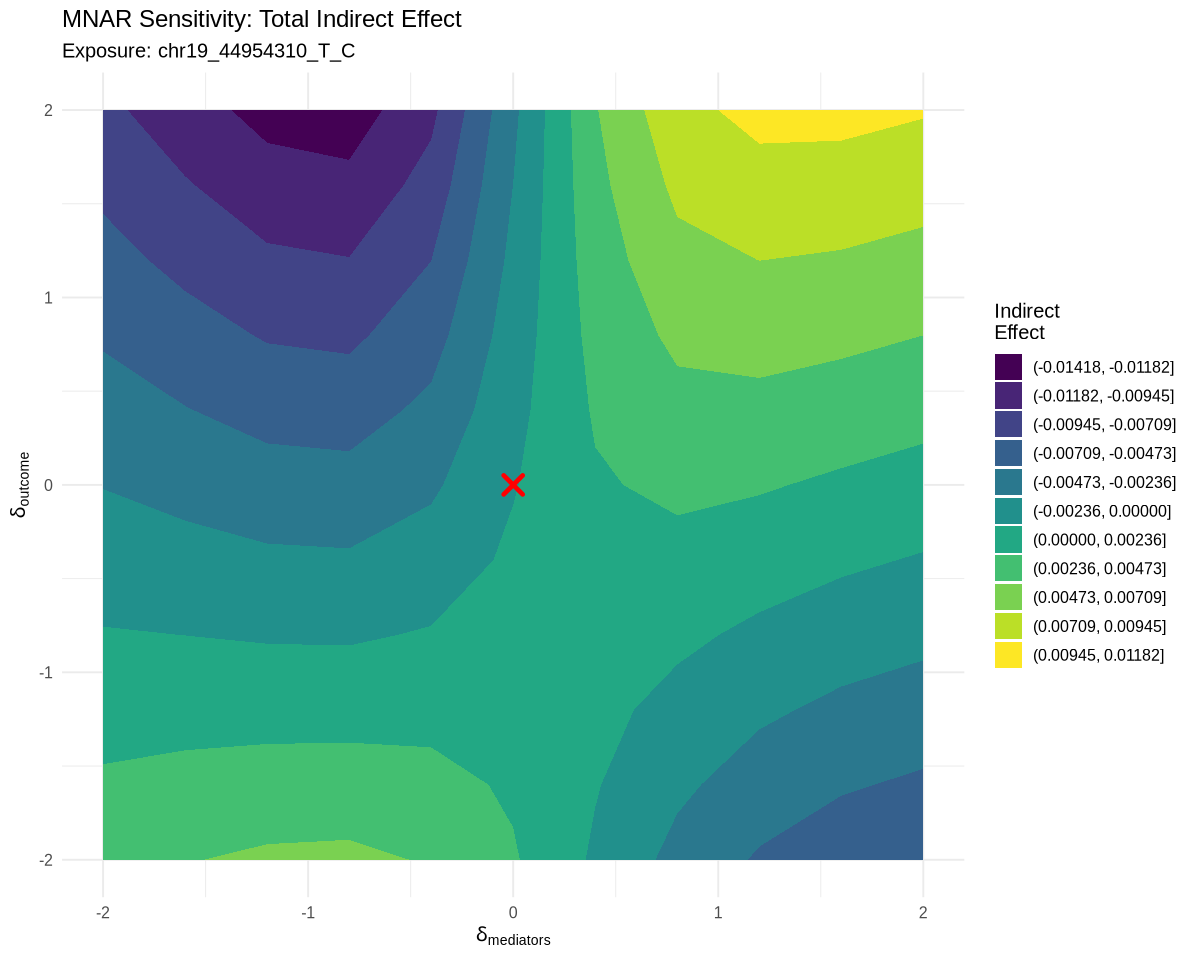

MNAR contour plots saved.


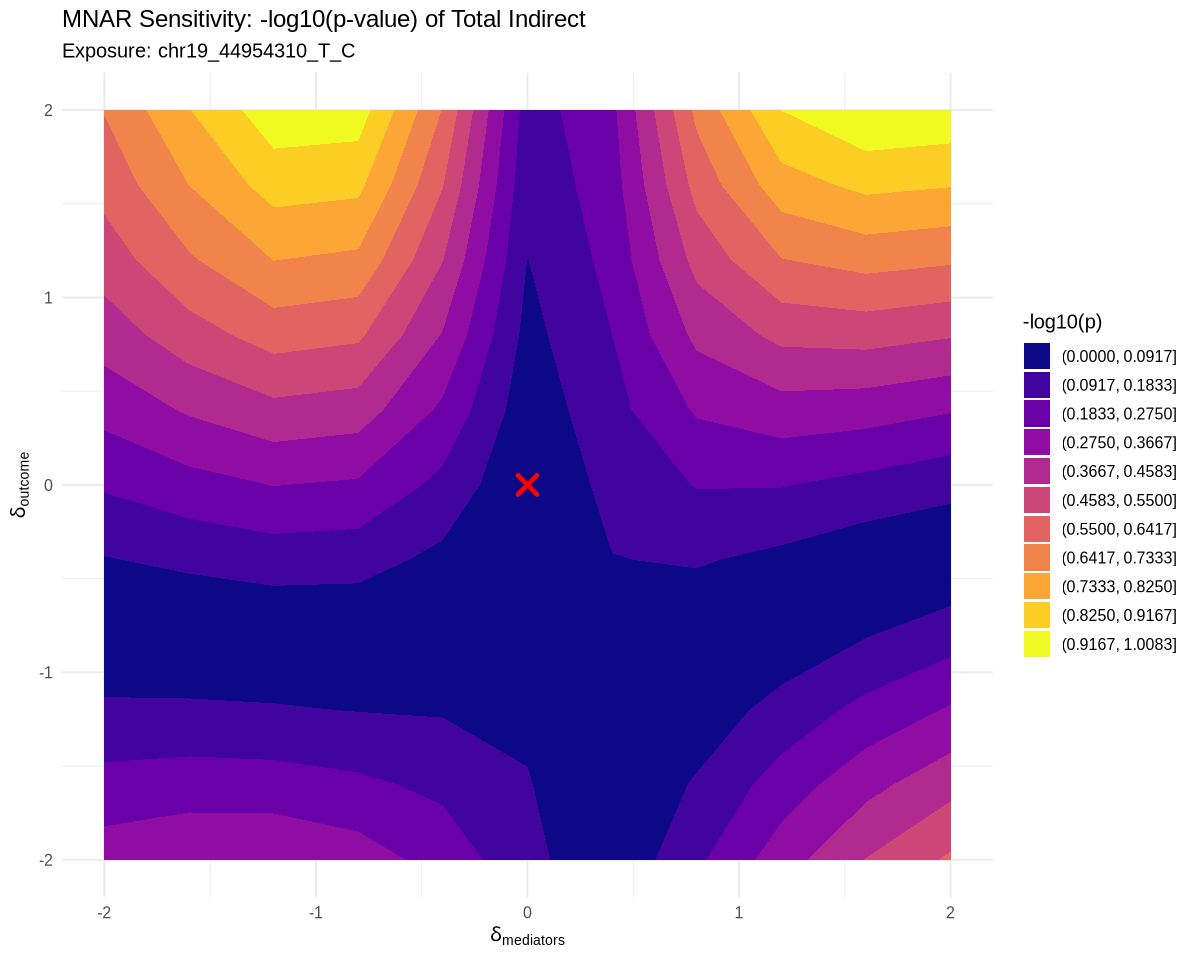

In [15]:
# ============================================================
# 7c. MNAR Contour Plots
# ============================================================
ti_data <- mnar_results[mnar_results$param == "total_indirect", ]

if (nrow(ti_data) > 0) {
  p_cont_ind <- ggplot(ti_data, aes(x=delta_med, y=delta_out, z=est)) +
    geom_contour_filled(bins=12) +
    scale_fill_viridis_d(option="viridis") +
    geom_point(data=data.frame(x=0, y=0), aes(x=x, y=y, z=NULL),
               shape=4, size=4, color="red", stroke=2) +
    labs(title="MNAR Sensitivity: Total Indirect Effect",
         subtitle=paste0("Exposure: ", EXPOSURE),
         x=expression(delta[mediators]), y=expression(delta[outcome]),
         fill="Indirect\nEffect") +
    theme_minimal(base_size=12)

  print(p_cont_ind)
  ggsave(file.path(DIR_MNAR, paste0("mnar_contour_indirect_", EXPOSURE, ".png")),
         p_cont_ind, width=8, height=6, dpi=150)
  ggsave(file.path(DIR_MNAR, paste0("mnar_contour_indirect_", EXPOSURE, ".pdf")),
         p_cont_ind, width=8, height=6)

  ti_data$neg_log10_p <- -log10(pmax(ti_data$pvalue, 1e-16))

  p_cont_pv <- ggplot(ti_data, aes(x=delta_med, y=delta_out, z=neg_log10_p)) +
    geom_contour_filled(bins=12) +
    scale_fill_viridis_d(option="plasma") +
    geom_point(data=data.frame(x=0, y=0), aes(x=x, y=y, z=NULL),
               shape=4, size=4, color="red", stroke=2) +
    labs(title="MNAR Sensitivity: -log10(p-value) of Total Indirect",
         subtitle=paste0("Exposure: ", EXPOSURE),
         x=expression(delta[mediators]), y=expression(delta[outcome]),
         fill="-log10(p)") +
    theme_minimal(base_size=12)

  print(p_cont_pv)
  ggsave(file.path(DIR_MNAR, paste0("mnar_contour_pvalue_", EXPOSURE, ".png")),
         p_cont_pv, width=8, height=6, dpi=150)
  ggsave(file.path(DIR_MNAR, paste0("mnar_contour_pvalue_", EXPOSURE, ".pdf")),
         p_cont_pv, width=8, height=6)

  cat("MNAR contour plots saved.\n")
}


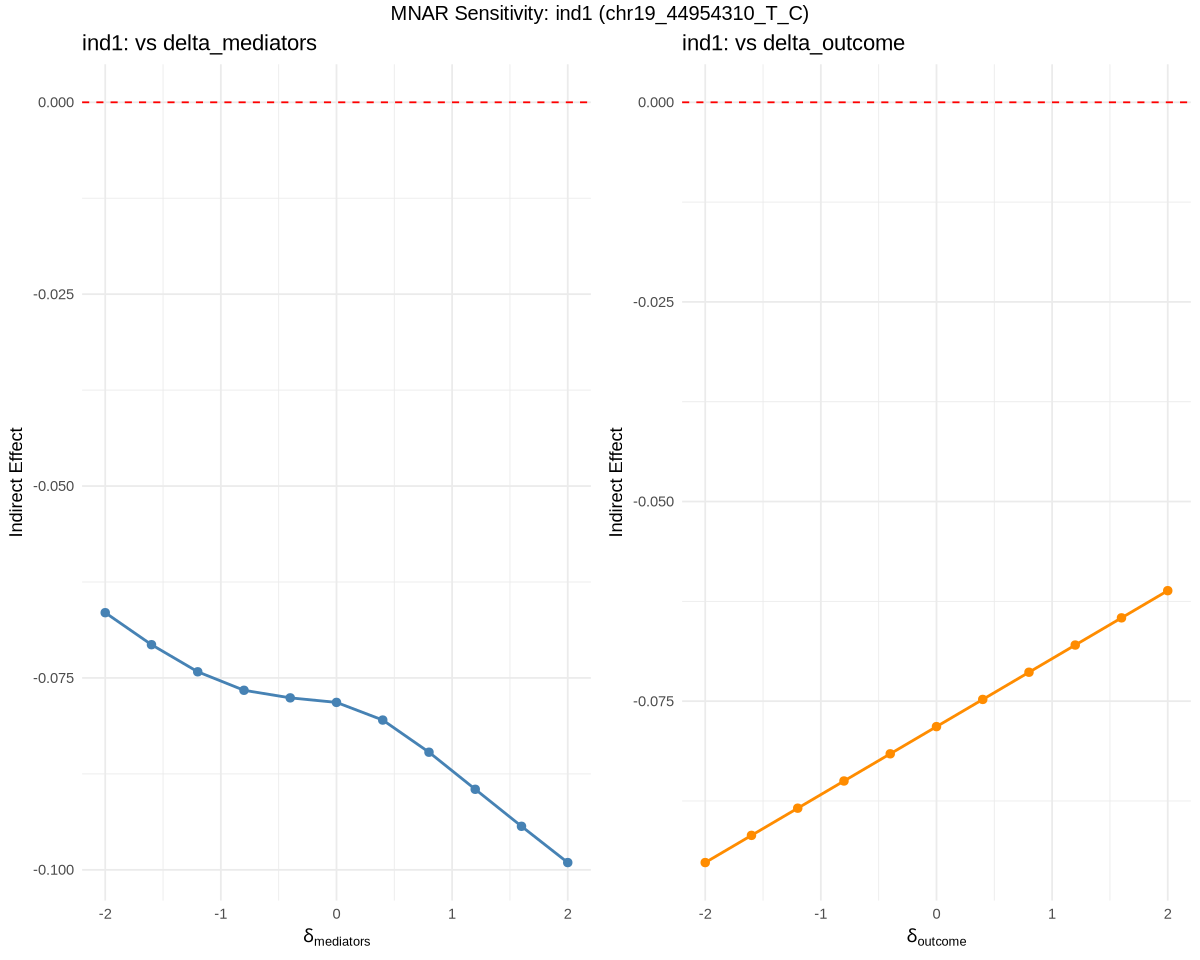

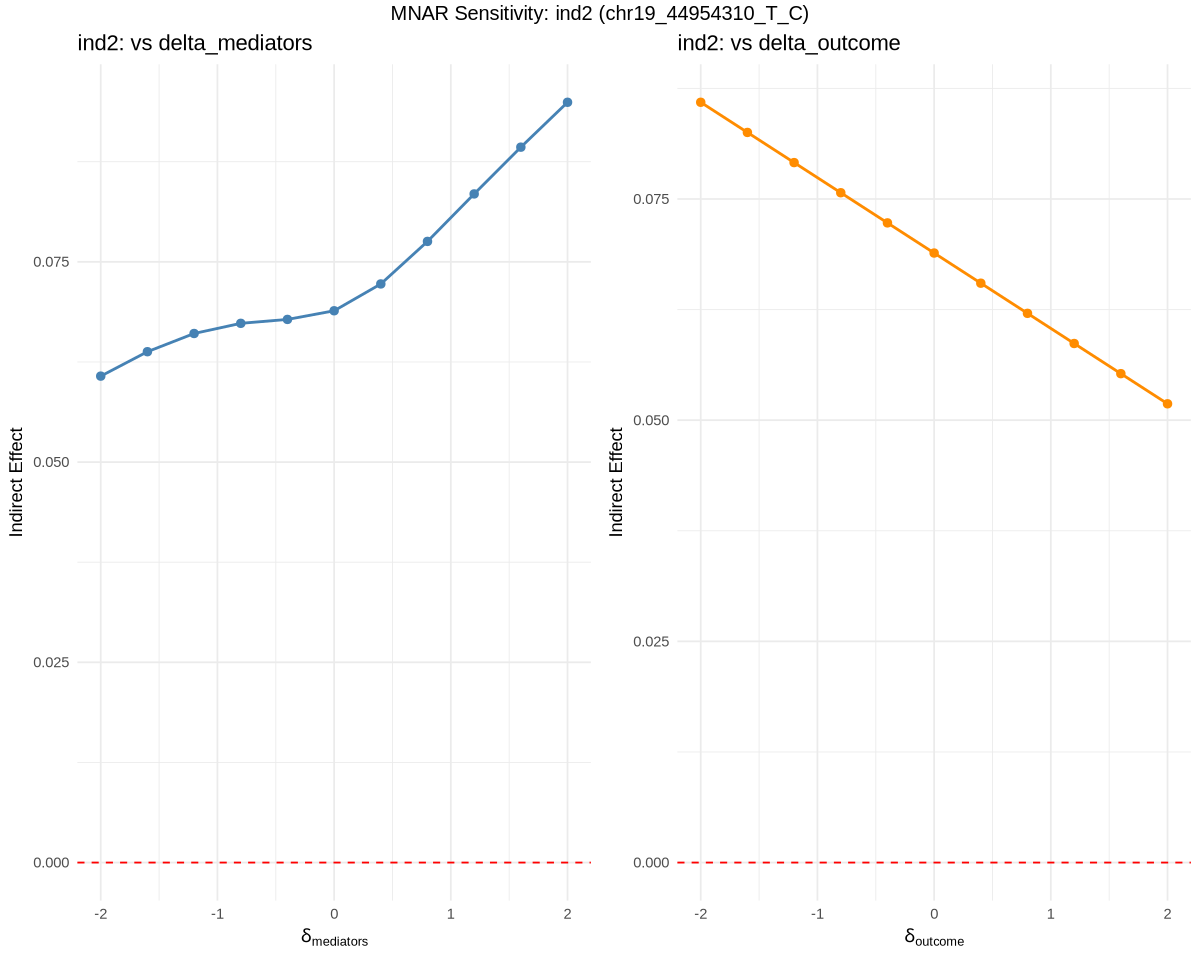

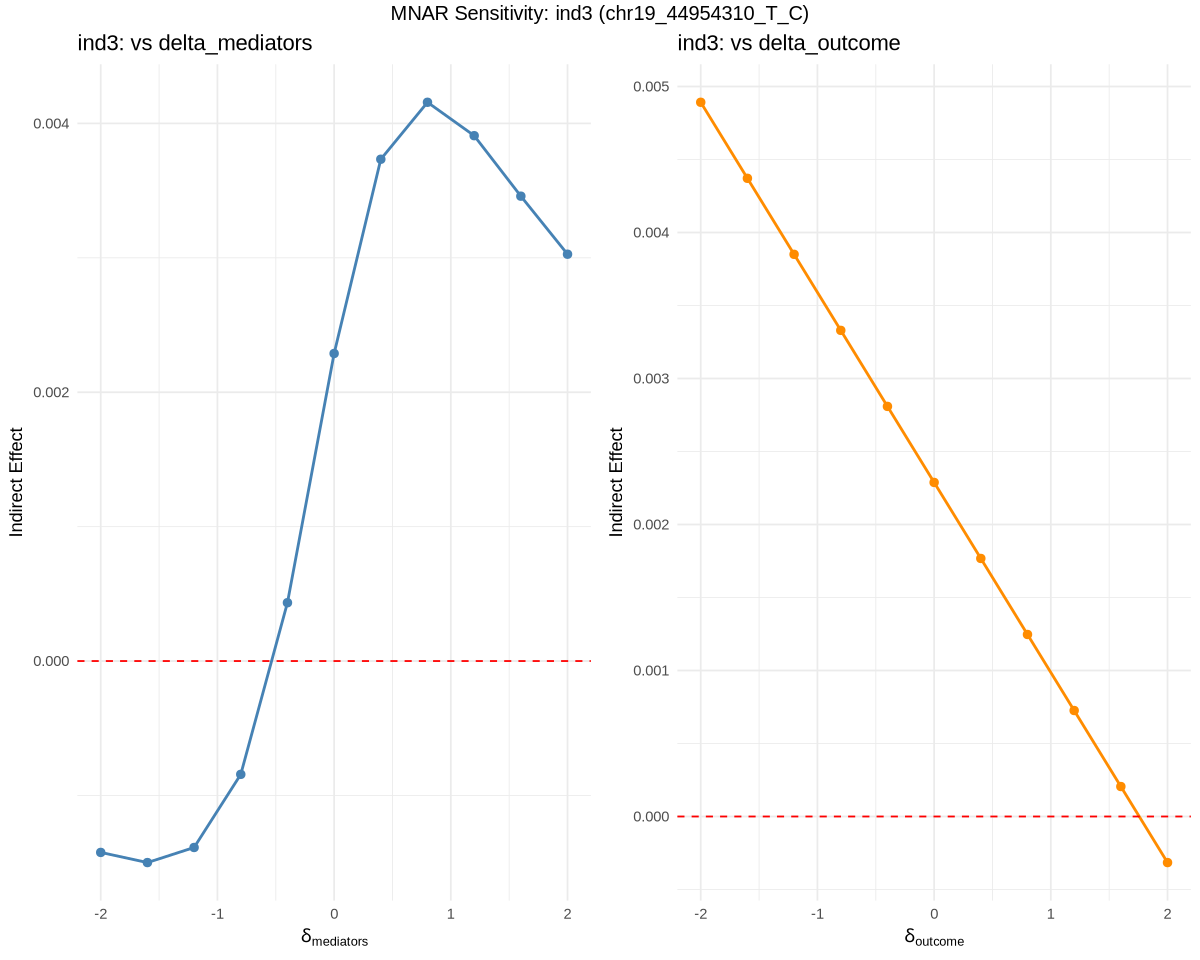

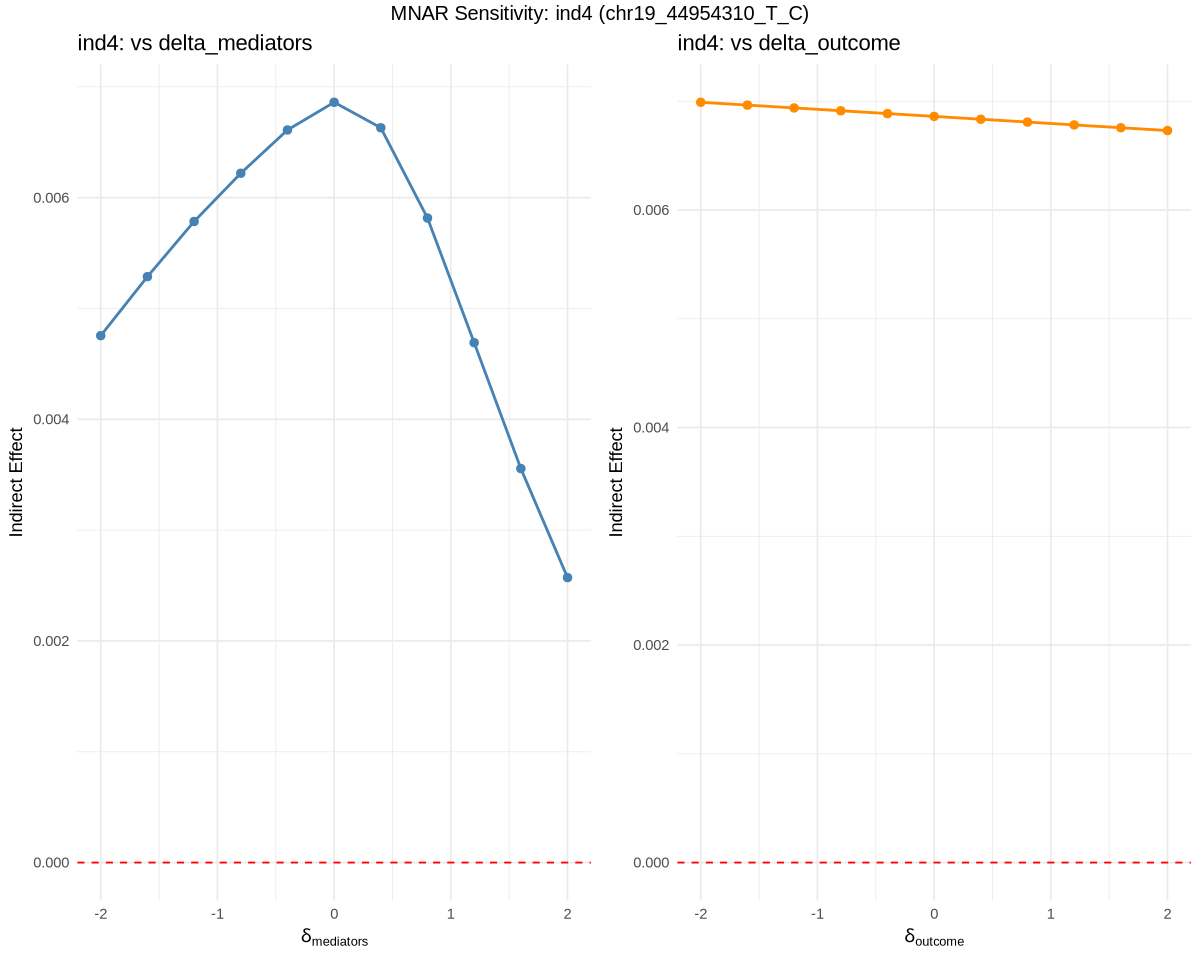

MNAR 1D slice plots saved.


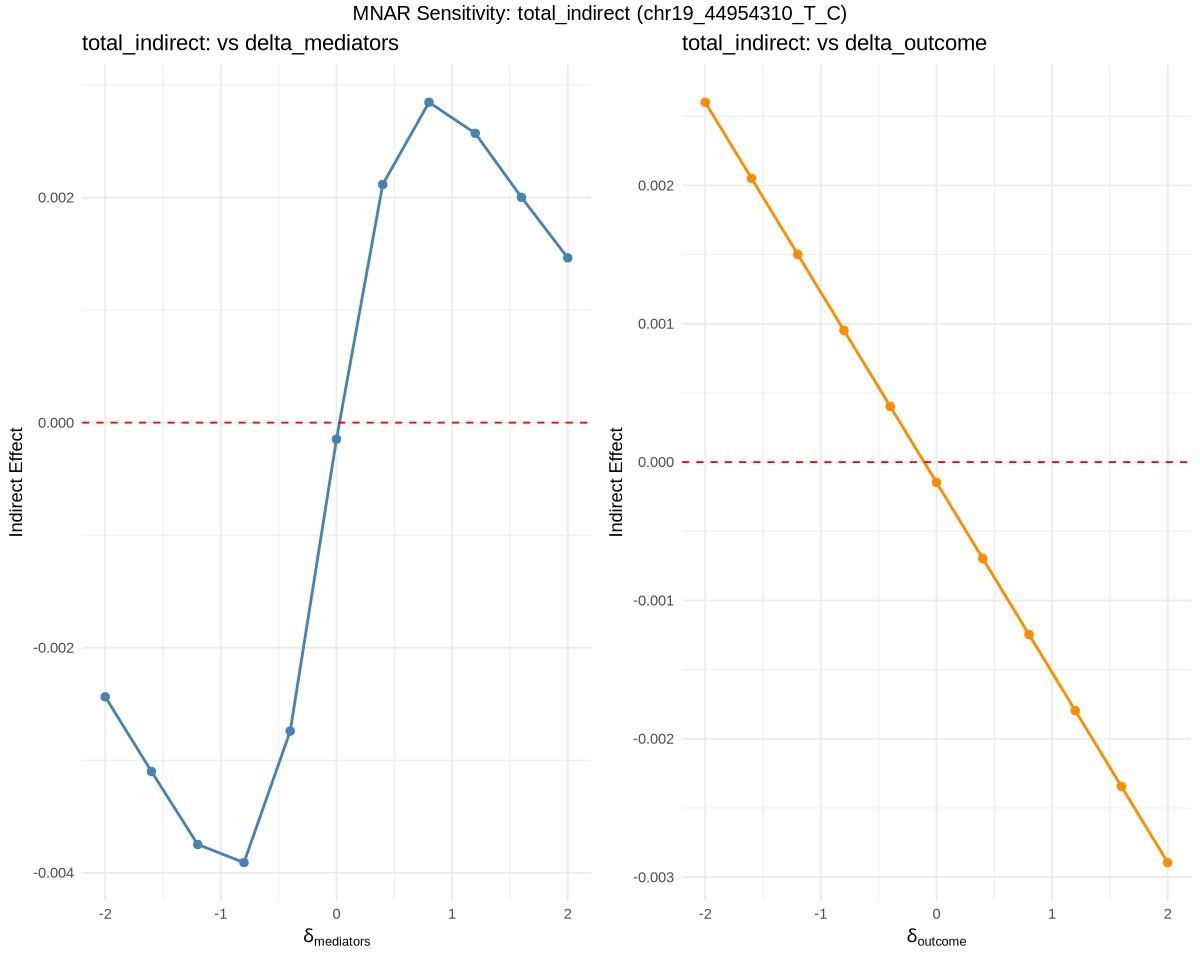

In [16]:
# ============================================================
# 7d. MNAR 1D Slice Plots
# ============================================================
for (param in c(paste0("ind", 1:n_med), "total_indirect")) {
  param_data <- mnar_results[mnar_results$param == param, ]

  slice_m <- param_data[param_data$delta_out == 0, ]
  slice_y <- param_data[param_data$delta_med == 0, ]

  p_left <- ggplot(slice_m, aes(x=delta_med, y=est)) +
    geom_line(color="steelblue", linewidth=0.8) +
    geom_point(color="steelblue", size=2) +
    geom_hline(yintercept=0, linetype="dashed", color="red") +
    labs(title=paste0(param, ": vs delta_mediators"),
         x=expression(delta[mediators]), y="Indirect Effect") +
    theme_minimal(base_size=11)

  p_right <- ggplot(slice_y, aes(x=delta_out, y=est)) +
    geom_line(color="darkorange", linewidth=0.8) +
    geom_point(color="darkorange", size=2) +
    geom_hline(yintercept=0, linetype="dashed", color="red") +
    labs(title=paste0(param, ": vs delta_outcome"),
         x=expression(delta[outcome]), y="Indirect Effect") +
    theme_minimal(base_size=11)

  g_slice <- grid.arrange(p_left, p_right, ncol=2,
    top=paste0("MNAR Sensitivity: ", param, " (", EXPOSURE, ")"))

  fname <- paste0("mnar_1d_slices_", param, "_", EXPOSURE)
  ggsave(file.path(DIR_MNAR, paste0(fname, ".png")), g_slice, width=12, height=5, dpi=150)
  ggsave(file.path(DIR_MNAR, paste0(fname, ".pdf")), g_slice, width=12, height=5)
}
cat("MNAR 1D slice plots saved.\n")


### MNAR Interpretation

The tipping point analysis identifies how large the systematic difference between observed
and missing subjects must be (in SD units) before the mediation finding becomes non-significant.
A large tipping distance (> 1 SD) suggests robustness; a small one (< 0.5 SD) suggests vulnerability.

---

## Method 4: Bayesian SEM (blavaan/Stan)

In [17]:
# ============================================================
# 8. Bayesian SEM (blavaan)
# ============================================================
cat("Fitting Bayesian SEM via blavaan/Stan...\n")
cat("This may take a long time for model compilation and MCMC sampling.\n\n")

N_CHAINS  <- 2
N_BURNIN  <- 500
N_SAMPLE  <- 1000

fit_bayes <- tryCatch(
  bsem(model_str, data=dat, fixed.x=FALSE, target="stan",
       n.chains=N_CHAINS, burnin=N_BURNIN, sample=N_SAMPLE, seed=42),
  error = function(e) {
    cat("blavaan error:", e$message, "\n")
    NULL
  }
)

if (!is.null(fit_bayes)) {
  cat("Bayesian SEM fit complete.\n")
  N_bayes <- lavInspect(fit_bayes, "ntotal")
  cat("N used:", N_bayes, "\n")
} else {
  cat("Bayesian SEM failed. Will skip Bayesian results.\n")
  N_bayes <- NA
}

Fitting Bayesian SEM via blavaan/Stan...


This may take a long time for model compilation and MCMC sampling.




SAMPLING FOR MODEL 'stanmarg' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.007789 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 77.89 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 1500 [  0%]  (Warmup)
Chain 1: Iteration:  150 / 1500 [ 10%]  (Warmup)
Chain 1: Iteration:  300 / 1500 [ 20%]  (Warmup)
Chain 1: Iteration:  450 / 1500 [ 30%]  (Warmup)
Chain 1: Iteration:  501 / 1500 [ 33%]  (Sampling)
Chain 1: Iteration:  650 / 1500 [ 43%]  (Sampling)
Chain 1: Iteration:  800 / 1500 [ 53%]  (Sampling)
Chain 1: Iteration:  950 / 1500 [ 63%]  (Sampling)
Chain 1: Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain 1: Iteration: 1250 / 1500 [ 83%]  (Sampling)
Chain 1: Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain 1: Iteration: 1500 / 1500 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 1051.11 seconds (Warm-up)
Chain 1:                2486.21 seconds (Sampling)
Chain 1:            

Warning message:
“There were 2000 transitions after warmup that exceeded the maximum treedepth. Increase max_treedepth above 10. See
https://mc-stan.org/misc/warnings.html#maximum-treedepth-exceeded”


Warning message:
“Examine the pairs() plot to diagnose sampling problems
”


Warning message:
“The largest R-hat is 1.55, indicating chains have not mixed.
Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.html#r-hat”


Warning message:
“Bulk Effective Samples Size (ESS) is too low, indicating posterior means and medians may be unreliable.
Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.html#bulk-ess”


Warning message:
“Tail Effective Samples Size (ESS) is too low, indicating posterior variances and tail quantiles may be unreliable.
Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.html#tail-ess”


Computing post-estimation metrics (including lvs if requested)...


Bayesian SEM fit complete.
N used: 1153 


In [18]:
# ============================================================
# 8b. Bayesian Results Extraction
# ============================================================
if (!is.null(fit_bayes)) {
  pt <- parTable(fit_bayes)
  labeled_bayes <- pt[pt$label != "", c("label", "est", "se")]

  draws_list <- blavInspect(fit_bayes, "draws")
  draws <- do.call(rbind, draws_list)

  cat("Posterior draws dimensions:", nrow(draws), "x", ncol(draws), "\n")
  cat("Draw column names:\n")
  print(colnames(draws))

  bayes_summary <- data.frame()

  target_labels <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                     paste0("ind", 1:n_med), "total_indirect", "total", "prop_med")

  for (lab in target_labels) {
    if (lab %in% colnames(draws)) {
      vals <- draws[, lab]
      ci <- quantile(vals, c(0.025, 0.975))
      pp <- mean(vals > 0)
      bayes_summary <- rbind(bayes_summary, data.frame(
        label = lab, post_mean = mean(vals), post_sd = sd(vals),
        ci_lower = ci[1], ci_upper = ci[2],
        P_positive = pp, pvalue = 2 * min(pp, 1 - pp),
        N = N_bayes, method = "Bayesian", stringsAsFactors = FALSE
      ))
    } else {
      pt_row <- labeled_bayes[labeled_bayes$label == lab, ]
      if (nrow(pt_row) > 0) {
        bayes_summary <- rbind(bayes_summary, data.frame(
          label = lab, post_mean = pt_row$est[1], post_sd = pt_row$se[1],
          ci_lower = pt_row$est[1] - 1.96*pt_row$se[1],
          ci_upper = pt_row$est[1] + 1.96*pt_row$se[1],
          P_positive = NA, pvalue = NA,
          N = N_bayes, method = "Bayesian", stringsAsFactors = FALSE
        ))
      }
    }
  }

  rownames(bayes_summary) <- NULL
  print(bayes_summary)
  write.csv(bayes_summary, file.path(DIR_BAYES, "bayesian_results.csv"), row.names=FALSE)
  cat("Bayesian results saved.\n")
}


Posterior draws dimensions: 2000 x 101 
Draw column names:
  [1] "a1"                                          
  [2] "APOC4_APOC2_AC_exp~msex_u"                   
  [3] "APOC4_APOC2_AC_exp~age_death_u"              
  [4] "APOC4_APOC2_AC_exp~pmi_u"                    
  [5] "APOC4_APOC2_AC_exp~ROS_study_u"              
  [6] "a2"                                          
  [7] "APOC2_AC_exp~msex_u"                         
  [8] "APOC2_AC_exp~age_death_u"                    
  [9] "APOC2_AC_exp~pmi_u"                          
 [10] "APOC2_AC_exp~ROS_study_u"                    
 [11] "a3"                                          
 [12] "APOC1_DeJager_Mic_exp~msex_u"                
 [13] "APOC1_DeJager_Mic_exp~age_death_u"           
 [14] "APOC1_DeJager_Mic_exp~pmi_u"                 
 [15] "a4"                                          
 [16] "APOE_Mega_Mic_exp~msex_u"                    
 [17] "APOE_Mega_Mic_exp~age_death_u"               
 [18] "APOE_Mega_Mic_exp~pmi_u"         

No id variables; using all as measure variables



Bayesian posterior plots saved.


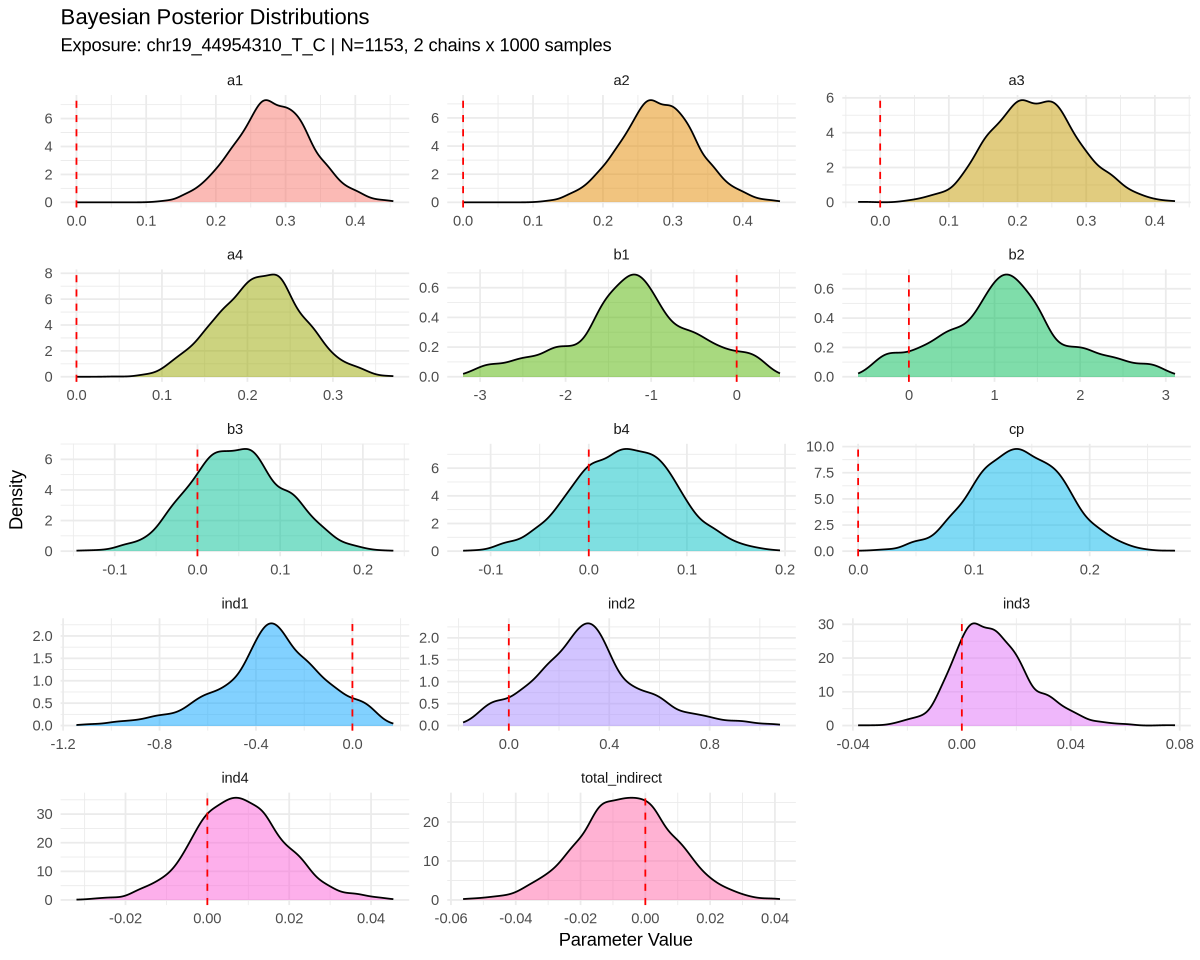

In [19]:
# ============================================================
# 8c. Bayesian Posterior Density Plots
# ============================================================
if (!is.null(fit_bayes)) {
  plot_params <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                   paste0("ind", 1:n_med), "total_indirect")
  avail_params <- intersect(plot_params, colnames(draws))

  if (length(avail_params) > 0) {
    draws_long <- reshape2::melt(as.data.frame(draws[, avail_params]),
                                variable.name="parameter", value.name="value")

    p_post <- ggplot(draws_long, aes(x=value, fill=parameter)) +
      geom_density(alpha=0.5) +
      geom_vline(xintercept=0, linetype="dashed", color="red") +
      facet_wrap(~parameter, scales="free", ncol=3) +
      labs(title="Bayesian Posterior Distributions",
           subtitle=paste0("Exposure: ", EXPOSURE, " | N=", N_bayes,
                           ", ", N_CHAINS, " chains x ", N_SAMPLE, " samples"),
           x="Parameter Value", y="Density") +
      theme_minimal(base_size=11) +
      theme(legend.position="none")

    n_panels <- length(avail_params)
    plot_h <- max(6, ceiling(n_panels / 3) * 3)

    print(p_post)
    ggsave(file.path(DIR_BAYES, paste0("bayesian_posteriors_", EXPOSURE, ".png")),
           p_post, width=12, height=plot_h, dpi=150)
    ggsave(file.path(DIR_BAYES, paste0("bayesian_posteriors_", EXPOSURE, ".pdf")),
           p_post, width=12, height=plot_h)
    cat("Bayesian posterior plots saved.\n")
  }
}


Bayesian trace plot saved.


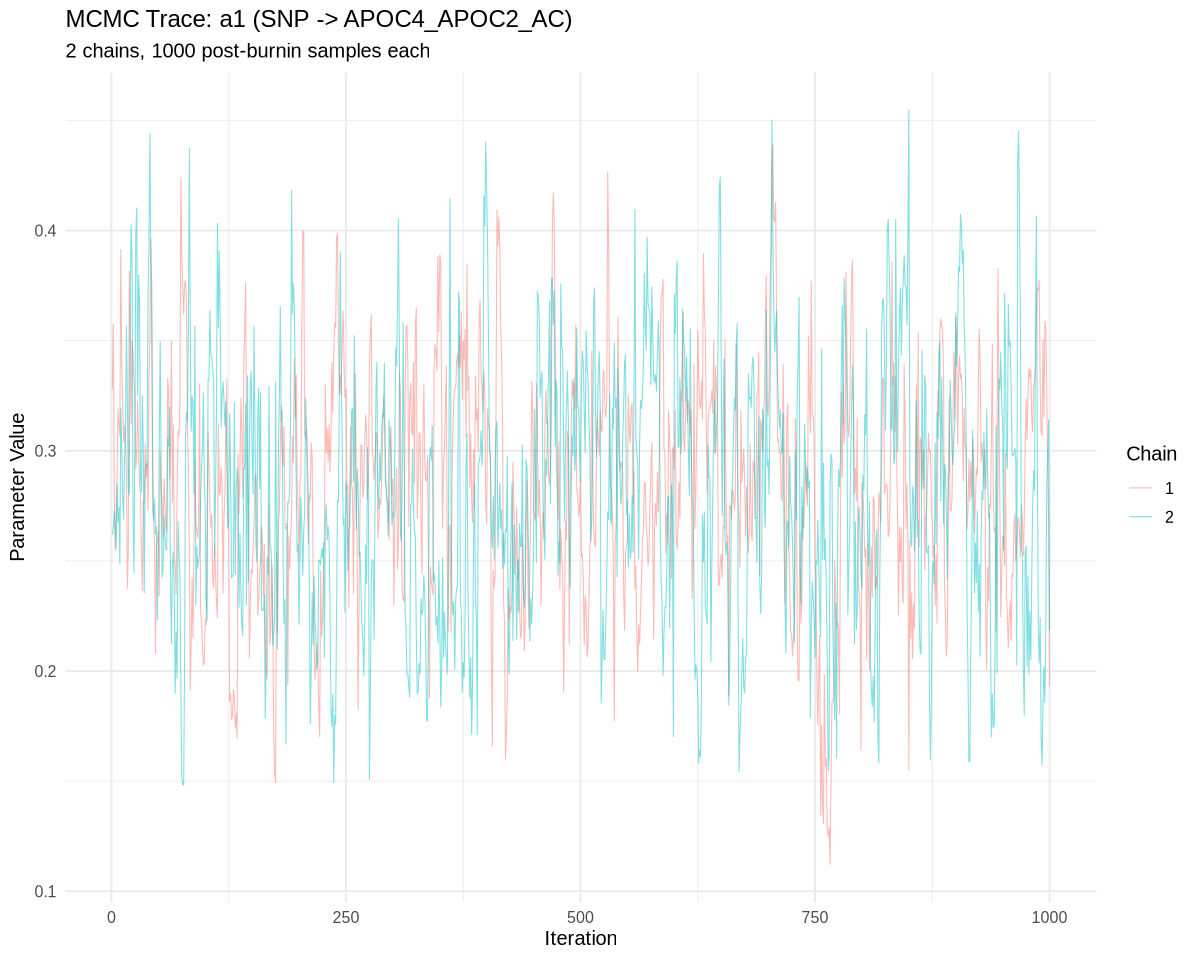

In [20]:
# ============================================================
# 8d. Bayesian Trace Plot
# ============================================================
if (!is.null(fit_bayes)) {
  a1_label <- "a1"
  if (a1_label %in% colnames(draws_list[[1]])) {
    trace_df <- data.frame()
    for (ch in seq_along(draws_list)) {
      chain_draws <- draws_list[[ch]]
      if (a1_label %in% colnames(chain_draws)) {
        trace_df <- rbind(trace_df, data.frame(
          iteration = 1:nrow(chain_draws),
          value = chain_draws[, a1_label],
          chain = as.factor(ch)
        ))
      }
    }

    if (nrow(trace_df) > 0) {
      p_trace <- ggplot(trace_df, aes(x=iteration, y=value, color=chain)) +
        geom_line(alpha=0.5, linewidth=0.3) +
        labs(title=paste0("MCMC Trace: a1 (SNP -> ", MED_LABELS[1], ")"),
             subtitle=paste0(N_CHAINS, " chains, ", N_SAMPLE, " post-burnin samples each"),
             x="Iteration", y="Parameter Value", color="Chain") +
        theme_minimal(base_size=12)

      print(p_trace)
      ggsave(file.path(DIR_BAYES, paste0("bayesian_trace_a_", EXPOSURE, ".png")),
             p_trace, width=10, height=4, dpi=150)
      ggsave(file.path(DIR_BAYES, paste0("bayesian_trace_a_", EXPOSURE, ".pdf")),
             p_trace, width=10, height=4)
      cat("Bayesian trace plot saved.\n")
    }
  } else {
    cat("a1 not found in draws columns. Skipping trace plot.\n")
  }
}


Bayesian forest plot saved.


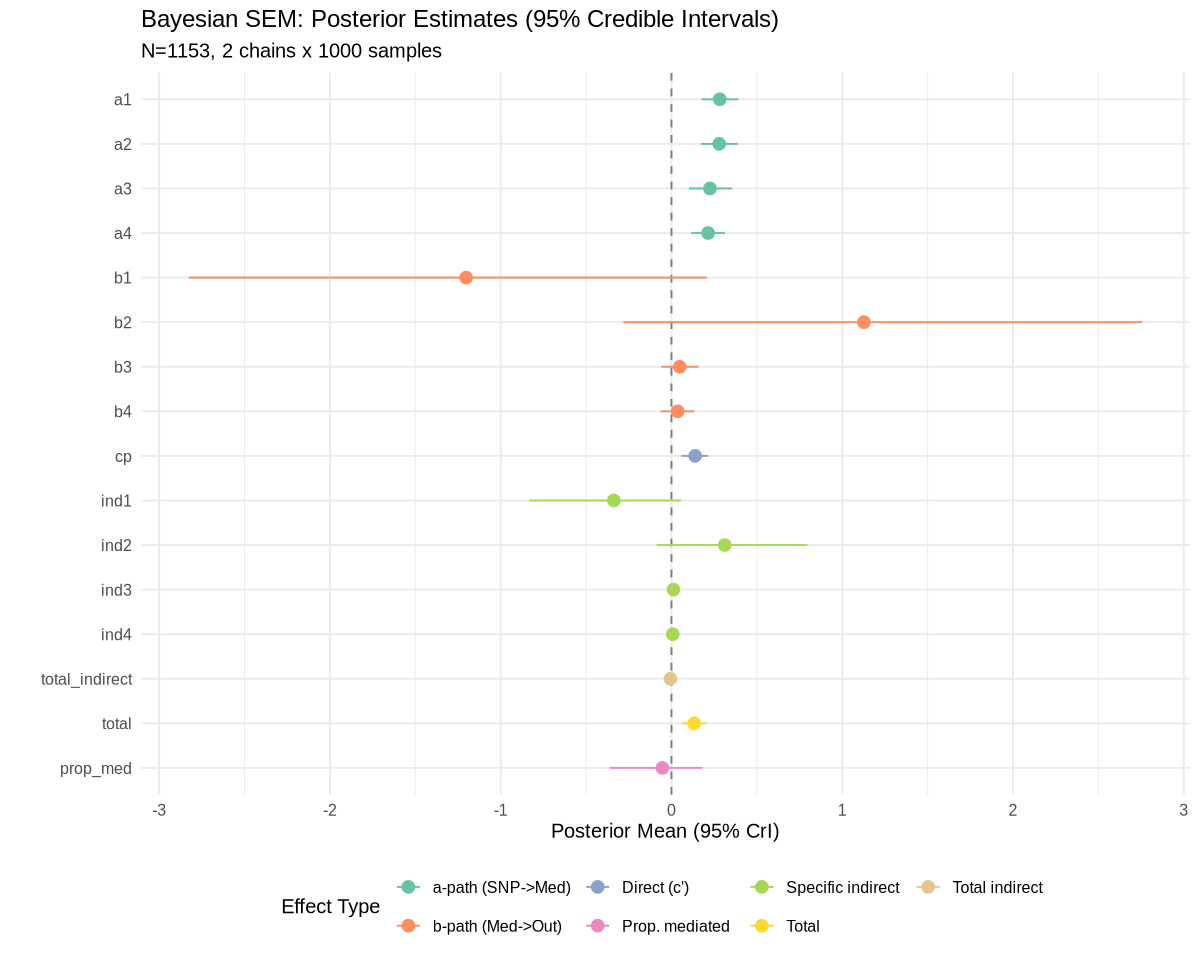

In [21]:
# ============================================================
# 8e. Bayesian Forest Plot
# ============================================================
if (!is.null(fit_bayes) && nrow(bayes_summary) > 0) {
  plot_bayes <- bayes_summary[!grepl("^diff_", bayes_summary$label), ]
  plot_bayes$label <- factor(plot_bayes$label,
    levels=rev(c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                 paste0("ind", 1:n_med), "total_indirect", "total", "prop_med")))

  plot_bayes$effect_type <- ifelse(grepl("^a", plot_bayes$label), "a-path (SNP->Med)",
                           ifelse(grepl("^b", plot_bayes$label), "b-path (Med->Out)",
                           ifelse(plot_bayes$label == "cp", "Direct (c')",
                           ifelse(grepl("^ind", plot_bayes$label), "Specific indirect",
                           ifelse(plot_bayes$label == "total_indirect", "Total indirect",
                           ifelse(plot_bayes$label == "total", "Total", "Prop. mediated"))))))

  p_bforest <- ggplot(plot_bayes, aes(x=post_mean, y=label, color=effect_type)) +
    geom_vline(xintercept=0, linetype="dashed", color="grey50") +
    geom_pointrange(aes(xmin=ci_lower, xmax=ci_upper), size=0.6) +
    scale_color_brewer(palette="Set2") +
    labs(title="Bayesian SEM: Posterior Estimates (95% Credible Intervals)",
         subtitle=paste0("N=", N_bayes, ", ", N_CHAINS, " chains x ", N_SAMPLE, " samples"),
         x="Posterior Mean (95% CrI)", y="", color="Effect Type") +
    theme_minimal(base_size=12) +
    theme(legend.position="bottom")

  print(p_bforest)
  ggsave(file.path(DIR_BAYES, "bayesian_forest_plot.png"), p_bforest, width=10, height=8, dpi=150)
  ggsave(file.path(DIR_BAYES, "bayesian_forest_plot.pdf"), p_bforest, width=10, height=8)
  cat("Bayesian forest plot saved.\n")
}


### Bayesian Interpretation

- **P(indirect > 0)**: Posterior probability that the indirect effect is positive.
- **95% Credible Interval**: Excludes zero = credibly non-zero.
- **Trace plots**: Good mixing (chains overlap) indicates convergence.

---

## Cross-Method Summary

In [22]:
# ============================================================
# 9. Cross-Method Summary
# ============================================================
all_summary <- data.frame()

# FIML
if (exists("labeled") && nrow(labeled) > 0) {
  fiml_rows <- data.frame(
    exposure = EXPOSURE, method = "FIML", label = labeled$label,
    est = labeled$est, se = labeled$se,
    ci_lower = labeled$ci.lower, ci_upper = labeled$ci.upper,
    pvalue = labeled$pvalue, ci_type = "Wald",
    n_eff = paste0("N=", N_fiml, " (FIML)"), stringsAsFactors = FALSE
  )
  all_summary <- rbind(all_summary, fiml_rows)
}

# Bootstrap
if (exists("boot_summary") && nrow(boot_summary) > 0) {
  boot_rows <- data.frame(
    exposure = EXPOSURE, method = "Bootstrap", label = boot_summary$label,
    est = boot_summary$boot_mean, se = boot_summary$boot_se,
    ci_lower = boot_summary$ci_lower, ci_upper = boot_summary$ci_upper,
    pvalue = boot_summary$pvalue, ci_type = "Percentile",
    n_eff = paste0("N=", N_fiml, " (Bootstrap FIML)"), stringsAsFactors = FALSE
  )
  all_summary <- rbind(all_summary, boot_rows)
}

# Bayesian
if (exists("bayes_summary") && nrow(bayes_summary) > 0) {
  bayes_rows <- data.frame(
    exposure = EXPOSURE, method = "Bayesian", label = bayes_summary$label,
    est = bayes_summary$post_mean, se = bayes_summary$post_sd,
    ci_lower = bayes_summary$ci_lower, ci_upper = bayes_summary$ci_upper,
    pvalue = bayes_summary$pvalue, ci_type = "Credible",
    n_eff = paste0("N=", N_bayes, " (Bayesian)"), stringsAsFactors = FALSE
  )
  all_summary <- rbind(all_summary, bayes_rows)
}

rownames(all_summary) <- NULL
print(all_summary)
write.csv(all_summary, file.path(DIR_SUMM, "all_methods_summary.csv"), row.names=FALSE)
cat("\nCross-method summary saved.\n")


             exposure    method          label          est         se
1  chr19_44954310_T_C      FIML             a1  0.279039981 0.05603136
2  chr19_44954310_T_C      FIML             a2  0.275817440 0.05611711
3  chr19_44954310_T_C      FIML             a3  0.225523125 0.06399825
4  chr19_44954310_T_C      FIML             a4  0.212803701 0.04913284
5  chr19_44954310_T_C      FIML             b1 -0.857552348 0.94555878
6  chr19_44954310_T_C      FIML             b2  0.779718372 0.94483110
7  chr19_44954310_T_C      FIML             b3  0.053666933 0.05799306
8  chr19_44954310_T_C      FIML             b4  0.032936786 0.05053026
9  chr19_44954310_T_C      FIML             cp  0.140334493 0.04015525
10 chr19_44954310_T_C      FIML           ind1 -0.239291391 0.26836798
11 chr19_44954310_T_C      FIML           ind2  0.215059926 0.26435836
12 chr19_44954310_T_C      FIML           ind3  0.012103134 0.01375153
13 chr19_44954310_T_C      FIML           ind4  0.007009070 0.01087676
14 chr


Cross-method summary saved.


In [23]:
# ============================================================
# 9b. Summary Display Table (wide format)
# ============================================================
fmt_pval <- function(p) {
  if (is.na(p)) return(NA)
  if (p < 0.001) return("<0.001")
  return(sprintf("%.4f", p))
}

display_labels <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                    paste0("ind", 1:n_med), "total_indirect", "total", "prop_med")

display_df <- data.frame(Effect = character(), stringsAsFactors=FALSE)

for (lab in display_labels) {
  row_data <- list(Effect = lab)
  for (meth in c("FIML", "Bootstrap", "Bayesian")) {
    r <- all_summary[all_summary$label == lab & all_summary$method == meth, ]
    if (nrow(r) > 0) {
      row_data[[paste0(meth, "_est_CI")]] <- sprintf("%.4f [%.4f, %.4f]",
                                                      r$est[1], r$ci_lower[1], r$ci_upper[1])
      row_data[[paste0(meth, "_p")]] <- fmt_pval(r$pvalue[1])
    } else {
      row_data[[paste0(meth, "_est_CI")]] <- NA
      row_data[[paste0(meth, "_p")]] <- NA
    }
  }
  display_df <- rbind(display_df, as.data.frame(row_data, stringsAsFactors=FALSE))
}

print(display_df)
write.csv(display_df, file.path(DIR_SUMM, paste0("summary_display_table_", EXPOSURE, ".csv")),
          row.names=FALSE)
cat("Display table saved.\n")

           Effect               FIML_est_CI FIML_p          Bootstrap_est_CI
1              a1   0.2790 [0.1692, 0.3889] <0.001   0.2818 [0.1755, 0.3930]
2              a2   0.2758 [0.1658, 0.3858] <0.001   0.2786 [0.1734, 0.3885]
3              a3   0.2255 [0.1001, 0.3510] <0.001   0.2232 [0.0981, 0.3507]
4              a4   0.2128 [0.1165, 0.3091] <0.001   0.2122 [0.1187, 0.2965]
5              b1 -0.8576 [-2.7108, 0.9957] 0.3644 -0.9239 [-2.7848, 0.7574]
6              b2  0.7797 [-1.0721, 2.6316] 0.4092  0.8444 [-0.8449, 2.7066]
7              b3  0.0537 [-0.0600, 0.1673] 0.3548  0.0542 [-0.0714, 0.1762]
8              b4  0.0329 [-0.0661, 0.1320] 0.5145  0.0337 [-0.0684, 0.1399]
9              cp   0.1403 [0.0616, 0.2190] <0.001   0.1428 [0.0581, 0.2269]
10           ind1 -0.2393 [-0.7653, 0.2867] 0.3726 -0.2606 [-0.8468, 0.2108]
11           ind2  0.2151 [-0.3031, 0.7332] 0.4159  0.2355 [-0.2325, 0.8117]
12           ind3  0.0121 [-0.0148, 0.0391] 0.3788  0.0117 [-0.0157, 0.0424]

Display table saved.


Summary forest plot saved.


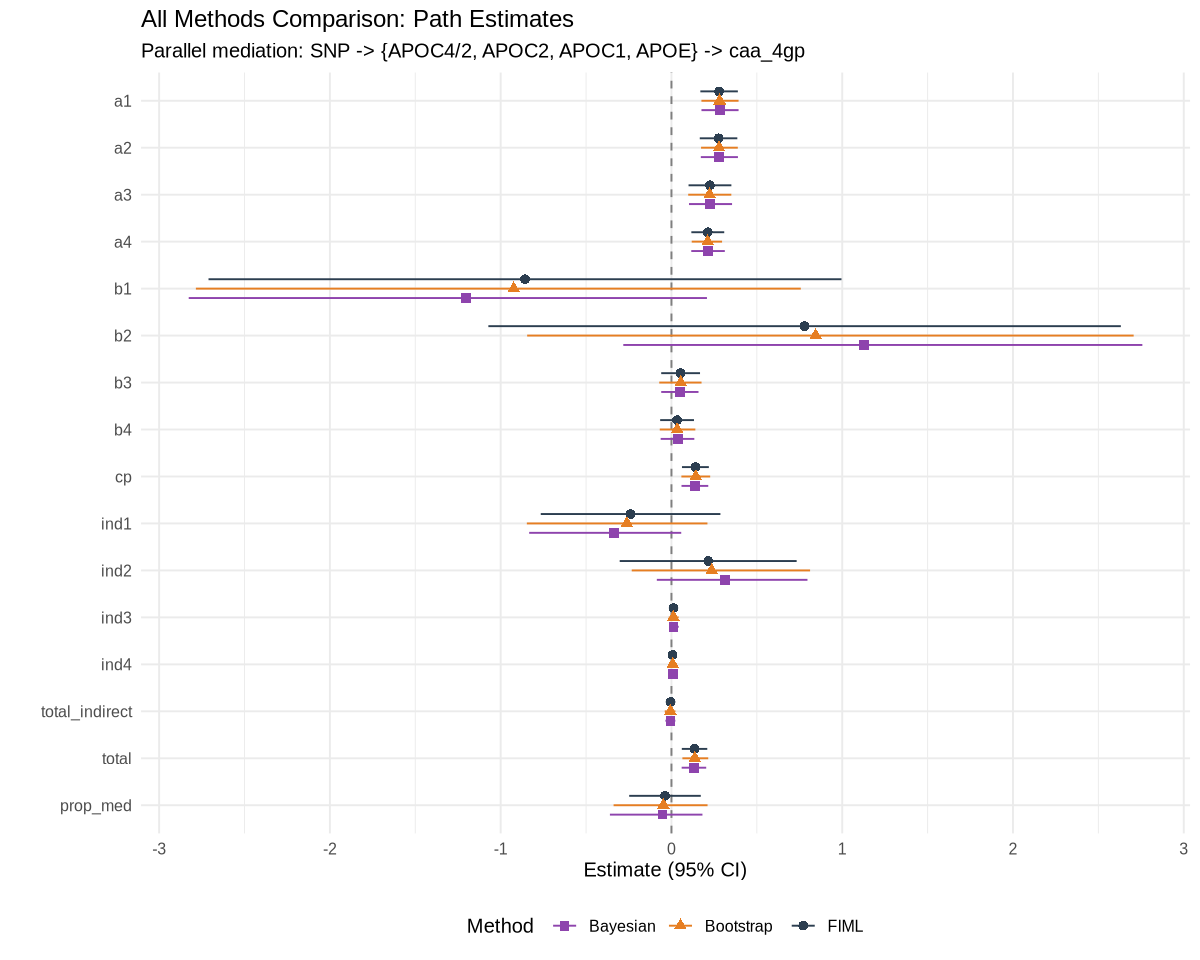

In [24]:
# ============================================================
# 9c. Summary Forest Plot: All Methods
# ============================================================
plot_labels <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                 paste0("ind", 1:n_med), "total_indirect", "total", "prop_med")
sm_plot <- all_summary[all_summary$label %in% plot_labels, ]
sm_plot$label <- factor(sm_plot$label, levels=rev(plot_labels))

p_all_forest <- ggplot(sm_plot, aes(x=est, y=label, color=method, shape=method)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(aes(xmin=ci_lower, xmax=ci_upper),
                  position=position_dodge(width=0.6), size=0.5) +
  scale_color_manual(values=c("FIML"="#2C3E50", "Bootstrap"="#E67E22", "Bayesian"="#8E44AD")) +
  scale_shape_manual(values=c("FIML"=16, "Bootstrap"=17, "Bayesian"=15)) +
  labs(title="All Methods Comparison: Path Estimates",
       subtitle="Parallel mediation: SNP -> {APOC4/2, APOC2, APOC1, APOE} -> caa_4gp",
       x="Estimate (95% CI)", y="", color="Method", shape="Method") +
  theme_minimal(base_size=12) +
  theme(legend.position="bottom")

print(p_all_forest)
ggsave(file.path(DIR_SUMM, "summary_forest_all_methods.png"), p_all_forest,
       width=11, height=9, dpi=150)
ggsave(file.path(DIR_SUMM, "summary_forest_all_methods.pdf"), p_all_forest,
       width=11, height=9)
cat("Summary forest plot saved.\n")


Faceted summary plot saved.


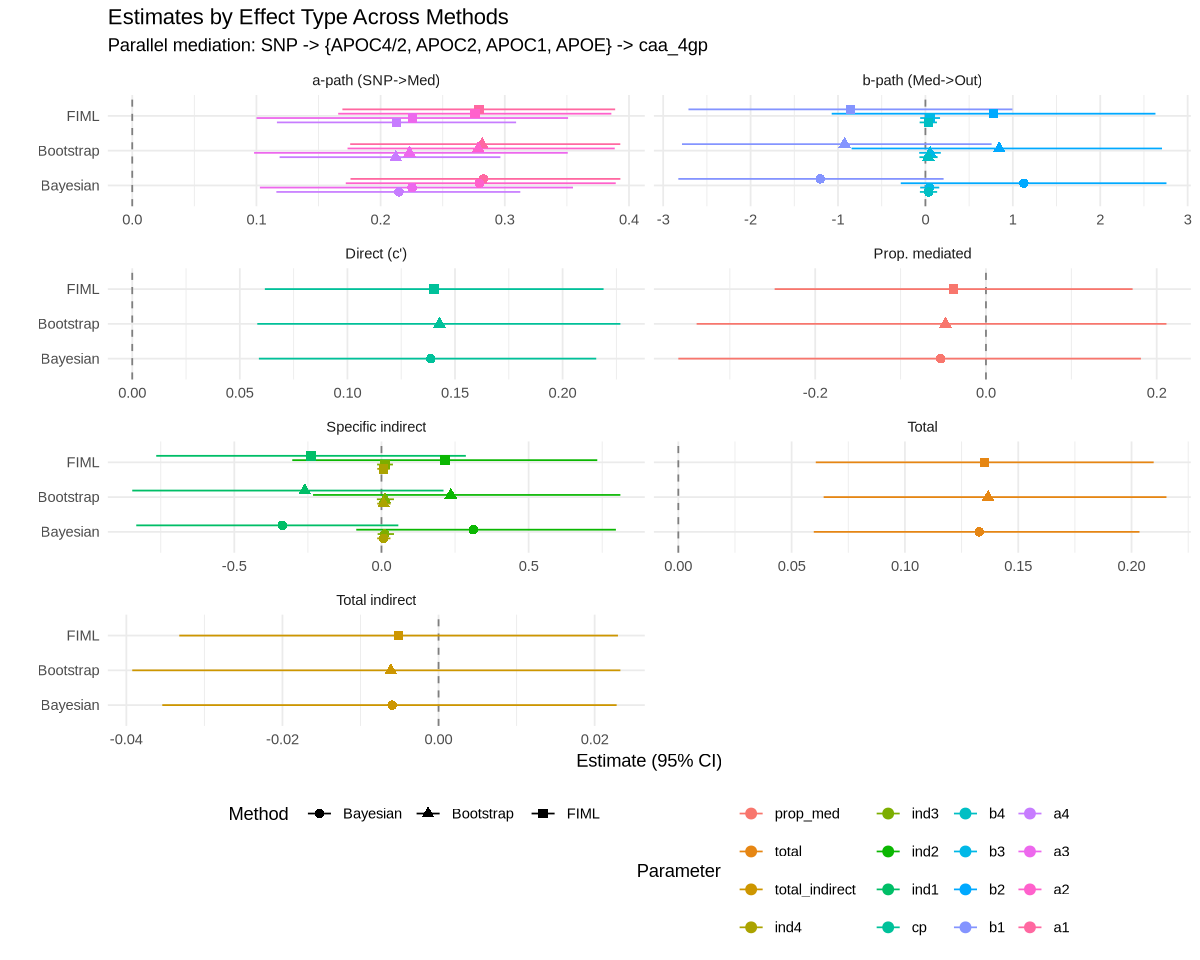

In [25]:
# ============================================================
# 9d. Summary: Faceted by Effect Type
# ============================================================
sm_plot2 <- sm_plot
sm_plot2$effect_type <- ifelse(grepl("^a", sm_plot2$label), "a-path (SNP->Med)",
                       ifelse(grepl("^b", sm_plot2$label), "b-path (Med->Out)",
                       ifelse(sm_plot2$label == "cp", "Direct (c')",
                       ifelse(grepl("^ind[0-9]", sm_plot2$label), "Specific indirect",
                       ifelse(sm_plot2$label == "total_indirect", "Total indirect",
                       ifelse(sm_plot2$label == "total", "Total", "Prop. mediated"))))))

p_facet <- ggplot(sm_plot2, aes(x=est, y=method, color=label, shape=method)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(aes(xmin=ci_lower, xmax=ci_upper),
                  position=position_dodge(width=0.5), size=0.5) +
  facet_wrap(~effect_type, scales="free_x", ncol=2) +
  labs(title="Estimates by Effect Type Across Methods",
       subtitle="Parallel mediation: SNP -> {APOC4/2, APOC2, APOC1, APOE} -> caa_4gp",
       x="Estimate (95% CI)", y="", color="Parameter", shape="Method") +
  theme_minimal(base_size=11) +
  theme(legend.position="bottom")

print(p_facet)
ggsave(file.path(DIR_SUMM, "summary_faceted_by_path.png"), p_facet,
       width=12, height=10, dpi=150)
ggsave(file.path(DIR_SUMM, "summary_faceted_by_path.pdf"), p_facet,
       width=12, height=10)
cat("Faceted summary plot saved.\n")


Indirect effect focus plot saved.


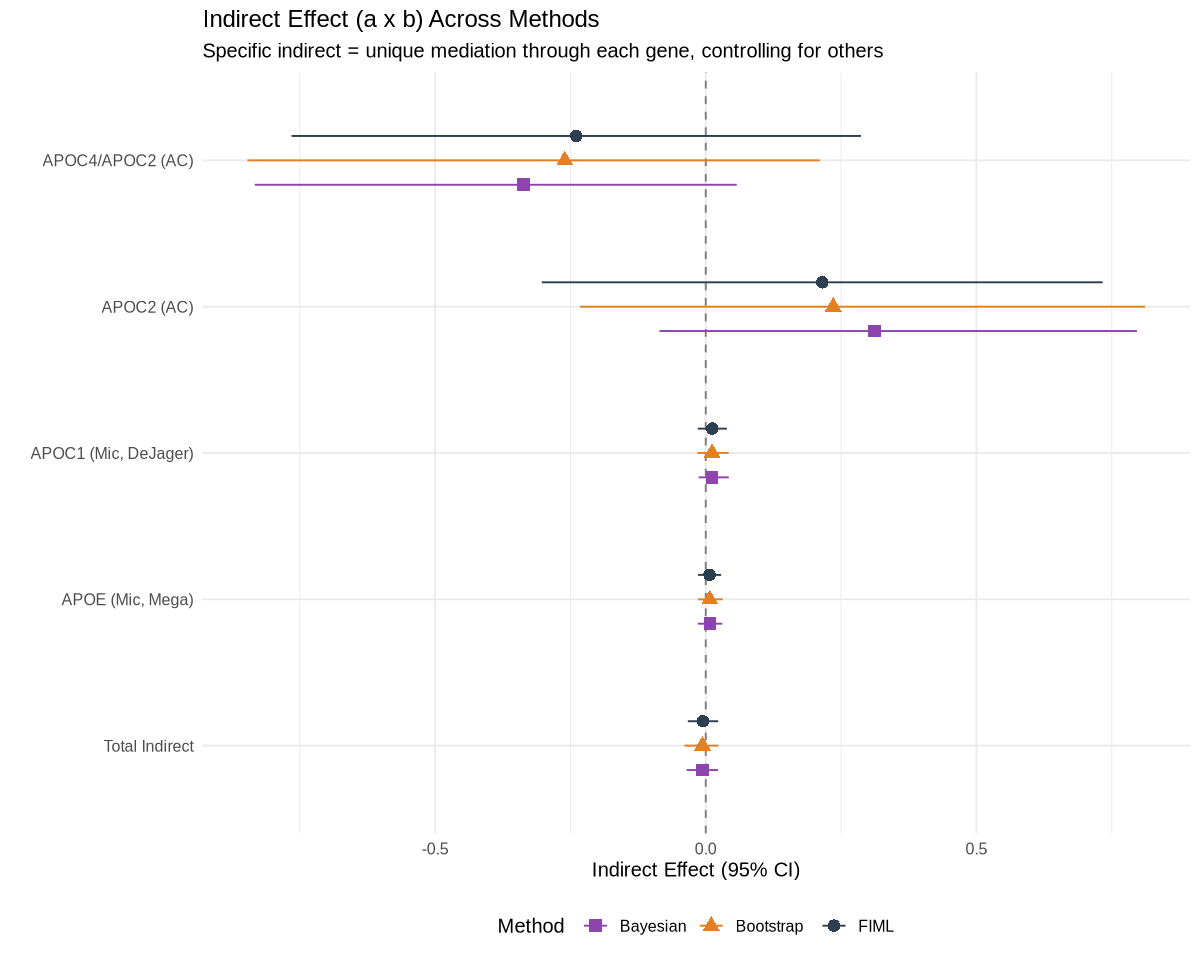

In [26]:
# ============================================================
# 9e. Summary: Indirect Effect Focus
# ============================================================
ind_focus <- all_summary[all_summary$label %in% c(paste0("ind", 1:n_med), "total_indirect"), ]

med_name_map <- c("ind1"="APOC4/APOC2 (AC)", "ind2"="APOC2 (AC)",
                  "ind3"="APOC1 (Mic, DeJager)", "ind4"="APOE (Mic, Mega)",
                  "total_indirect"="Total Indirect")
ind_focus$med_name <- med_name_map[ind_focus$label]
ind_focus$med_name <- factor(ind_focus$med_name,
  levels=rev(c("APOC4/APOC2 (AC)", "APOC2 (AC)", "APOC1 (Mic, DeJager)",
               "APOE (Mic, Mega)", "Total Indirect")))

p_indirect <- ggplot(ind_focus, aes(x=est, y=med_name, color=method, shape=method)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(aes(xmin=ci_lower, xmax=ci_upper),
                  position=position_dodge(width=0.5), size=0.7) +
  scale_color_manual(values=c("FIML"="#2C3E50", "Bootstrap"="#E67E22", "Bayesian"="#8E44AD")) +
  scale_shape_manual(values=c("FIML"=16, "Bootstrap"=17, "Bayesian"=15)) +
  labs(title="Indirect Effect (a x b) Across Methods",
       subtitle="Specific indirect = unique mediation through each gene, controlling for others",
       x="Indirect Effect (95% CI)", y="", color="Method", shape="Method") +
  theme_minimal(base_size=12) +
  theme(legend.position="bottom")

print(p_indirect)
ggsave(file.path(DIR_SUMM, "summary_indirect_effect.png"), p_indirect,
       width=10, height=5, dpi=150)
ggsave(file.path(DIR_SUMM, "summary_indirect_effect.pdf"), p_indirect,
       width=10, height=5)
cat("Indirect effect focus plot saved.\n")


Combined panel saved.


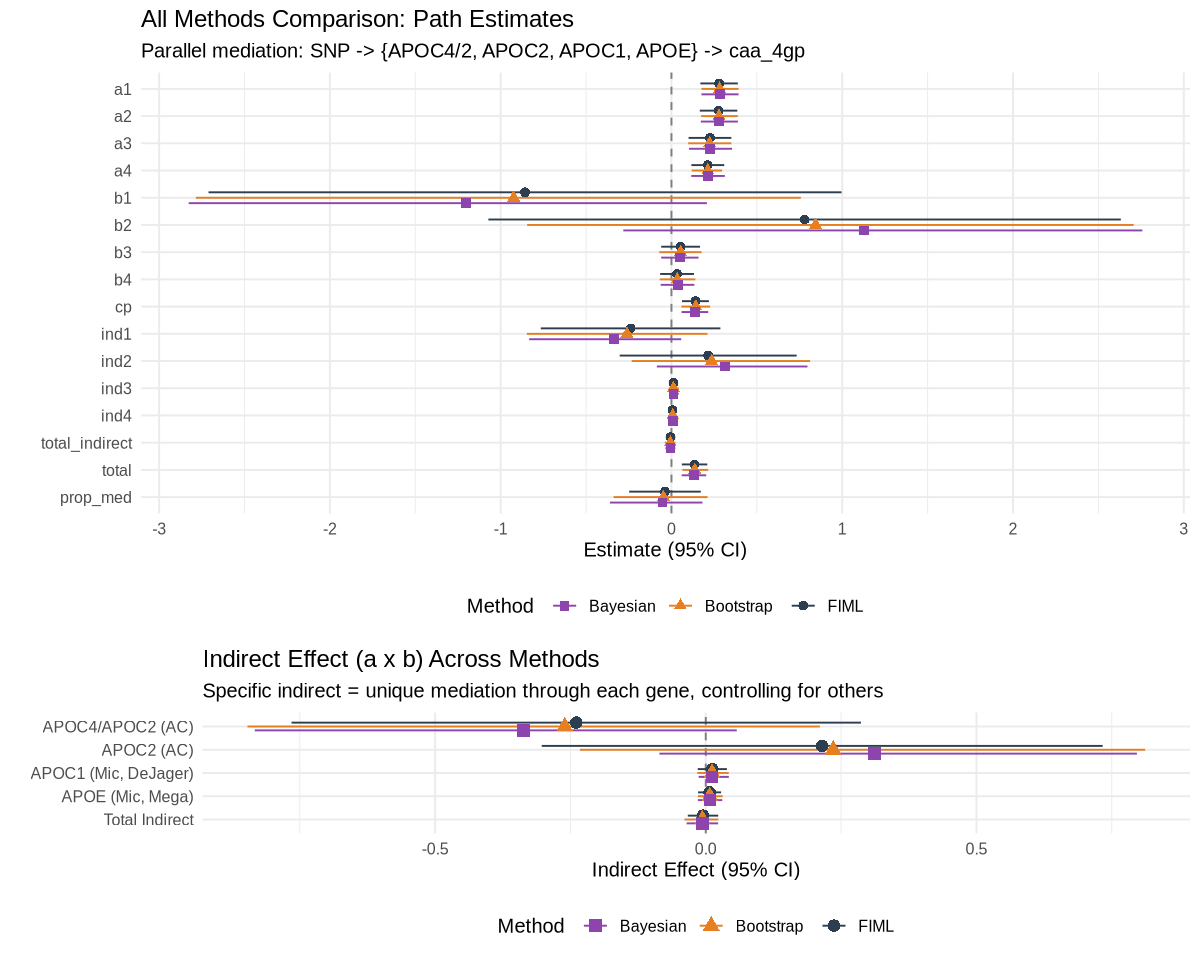

In [27]:
# ============================================================
# 9f. Summary: Combined Panel
# ============================================================
g_combined <- grid.arrange(p_all_forest, p_indirect, nrow=2, heights=c(2, 1))
ggsave(file.path(DIR_SUMM, "summary_combined_panel.png"), g_combined,
       width=11, height=14, dpi=150)
ggsave(file.path(DIR_SUMM, "summary_combined_panel.pdf"), g_combined,
       width=11, height=14)
cat("Combined panel saved.\n")


---

## Output File Inventory

In [29]:
# ============================================================
# 11. Output File Inventory
# ============================================================
cat("Output files in:", RESULT_DIR, "\n\n")

for (subdir in c("main_SEM_FIML", "bootstrap", "MNAR_sensitivity", "bayesian_blavaan", "summary")) {
  full_path <- file.path(RESULT_DIR, subdir)
  files <- list.files(full_path, full.names=FALSE)
  if (length(files) > 0) {
    cat(paste0(subdir, "/\n"))
    for (f in files) cat(paste0("  ", f, "\n"))
    cat("\n")
  }
}

top_files <- list.files(RESULT_DIR, full.names=FALSE, recursive=FALSE)
top_files <- top_files[!top_files %in% c("main_SEM_FIML", "bootstrap", "MNAR_sensitivity",
                                          "bayesian_blavaan", "summary", "log")]
if (length(top_files) > 0) {
  cat("Top-level files:\n")
  for (f in top_files) cat(paste0("  ", f, "\n"))
}


Output files in: /mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/caa_4gp 



main_SEM_FIML/
  fiml_all_paths.csv
  fiml_fit_measures.csv
  fiml_forest_plot.pdf
  fiml_forest_plot.png

bootstrap/
  bootstrap_distributions_chr19_44954310_T_C.pdf
  bootstrap_distributions_chr19_44954310_T_C.png
  bootstrap_forest_plot.pdf
  bootstrap_forest_plot.png
  bootstrap_results.csv

MNAR_sensitivity/
  mnar_1d_slices_ind1_chr19_44954310_T_C.pdf
  mnar_1d_slices_ind1_chr19_44954310_T_C.png
  mnar_1d_slices_ind2_chr19_44954310_T_C.pdf
  mnar_1d_slices_ind2_chr19_44954310_T_C.png
  mnar_1d_slices_ind3_chr19_44954310_T_C.pdf
  mnar_1d_slices_ind3_chr19_44954310_T_C.png
  mnar_1d_slices_ind4_chr19_44954310_T_C.pdf
  mnar_1d_slices_ind4_chr19_44954310_T_C.png
  mnar_1d_slices_total_indirect_chr19_44954310_T_C.pdf
  mnar_1d_slices_total_indirect_chr19_44954310_T_C.png
  mnar_contour_indirect_chr19_44954310_T_C.pdf
  mnar_contour_indirect_chr19_44954310_T_C.png
  mnar_contour_pvalue_chr19_44954310_T_C.pdf
  mnar_contour_pvalue_chr19_44954310_T_C.png
  mnar_grid_results.csv
  mnar_

Top-level files:
  APOE_ind_set_27_caa_4gp_mediation_all_input.txt
  APOE_ind_set_27_caa_4gp_SEM_mediation.ipynb
  run_reexecute.sh
  session_notes.md


In [30]:
# ============================================================
# 12. Save session_notes.md
# ============================================================
notes <- paste0(
  "# Session Notes: Parallel Mediation Analysis\n\n",
  "## Analysis Summary\n",
  "- **Date**: ", Sys.Date(), "\n",
  "- **Design**: Parallel (joint) mediation (Design 2)\n",
  "- **Direction**: Unidirectional (SNP -> M -> Y)\n",
  "- **Exposure**: chr19_44954310_T_C\n",
  "- **Mediators**: APOC4_APOC2_AC, APOC2_AC, APOC1_DeJager_Mic, APOE_Mega_Mic\n",
  "- **Outcome**: caa_4gp (cerebral amyloid angiopathy, 4-group ordinal)\n",
  "- **Total N**: ", nrow(dat), " (all subjects with SNP observed)\n\n",
  "## Methods\n",
  "1. FIML SEM (lavaan) - primary analysis, N=", N_fiml, "\n",
  "2. Bootstrap (", N_BOOT, " replicates, FIML inside each)\n",
  "3. MNAR sensitivity (delta-shift grid)\n",
  "4. Bayesian SEM (blavaan/Stan) - ", N_CHAINS, " chains x ", N_SAMPLE, " samples\n\n",
  "## Covariate Strategy\n",
  "Strategy A (covariates-in-model):\n",
  "- M1 & M2 (AC): msex_u, age_death_u, pmi_u, ROS_study_u\n",
  "- M3 & M4 (Mic): msex_u, age_death_u, pmi_u\n",
  "- Y (caa_4gp): educ, apoe4_dose, apoe2_dose, msex_u, age_death_u\n\n",
  "## Sample Sizes\n",
  "- SNP: 1153/1153\n",
  "- APOC4_APOC2_AC: 593/1153\n",
  "- APOC2_AC: 593/1153\n",
  "- APOC1_DeJager_Mic: 419/1153\n",
  "- APOE_Mega_Mic: 733/1153\n",
  "- caa_4gp: 1050/1153\n\n",
  "## Key Findings\n",
  "See all_methods_summary.csv and the conclusion section of the notebook.\n\n",
  "## Sensitivity Analysis\n",
  "A 3-mediator model excluding APOC4_APOC2_AC_exp was run to address collinearity\n",
  "between APOC4/APOC2 and APOC2 (both AC cortex). Results are in\n",
  "main_SEM_FIML/sensitivity_analysis/. See comparison_4med_vs_3med.csv.\n\n",
  "## Recommended Follow-up\n",
  "1. Test each mediator individually (Design 1) to compare specific vs marginal effects.\n",
  "2. Consider serial mediation if biological chain is hypothesized.\n",
  "3. E-value analysis for sensitivity to unmeasured confounding.\n"
)

writeLines(notes, file.path(RESULT_DIR, "session_notes.md"))
cat("session_notes.md saved.\n")


In [31]:
# ============================================================
# 13. Cleanup and Session Info
# ============================================================
temp_patterns <- c("lavExport*", "*.stan", "tmp_*", "*.bak")
for (pat in temp_patterns) {
  files <- Sys.glob(file.path(RESULT_DIR, pat))
  if (length(files) > 0) file.remove(files)
  files <- Sys.glob(pat)
  if (length(files) > 0) file.remove(files)
}

cat("\n--- Session Info ---\n")
sessionInfo()



--- Session Info ---


Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”


R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 24.04.3 LTS

Matrix products: default
BLAS/LAPACK: /mnt/lustre/home/yl4437/.pixi/envs/python/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
[1] reshape2_1.4.5 gridExtra_2.3  blavaan_0.5-10 Rcpp_1.1.1     lavaan_0.6-21 
[6] ggplot2_4.0.2 

loaded via a namespace (and not attached):
 [1] gtable_0.3.6          QuickJSR_1.9.0        inline_0.3.21        
 [4] CompQuadForm_1.4.4    lattice_0.22-9        quadprog_1.5-8 